<a href="https://colab.research.google.com/github/guolong1995/GPT/blob/main/day3_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 諸注意

- 本講座は金融取引に対する理論的かつ実践的な学びを提供するものですが、各自で実運用する際の利益を確約するものではありません

- 配布する資料について、情報の正確性について万全を期しておりますが、その内容について保証するものではありません

- 他の受講生や運営への迷惑行為は禁止

- 受講生以外への講義資料・講義動画の共有は固く禁止します
  - 禁止事項の例
    - SNSへのアップロード
    - Githubでコードを公開

- 本講義の内容についてSNSに投稿するのはお控えください

- Colabで実行する場合は、「ランタイム」→「ランタイムのタイプを変更」から、ランタイムのバージョンに「2026.04」を選択してください



# Day3. アクティブ運用の理論

Day2では、価格データからリターンや残差リターンを作り、戦略を評価する対象を定義しました。この回では、それらのリターンを使って、シグナルの予測力や運用成績をどう測るかを整理します。

アクティブ運用とは、市場ベンチマークを上回る超過収益（アルファ）を目指す投資戦略です。本講義では、アルファの厳密な定義から始まり、アクティブ運用のパフォーマンスを評価するための重要な指標であるInformation CoefficientとInformation Ratioについて解説します。
また、アクティブ運用の基本定理を導出し、シグナルの質と投資機会の数がパフォーマンスに与える影響を定量的に理解します。さらに、取引コストがアクティブ運用に与える影響についても考察します。

**ゴール**: アルファの定義を理解し、IC・IRを計算できるようになる。アクティブ運用の基本定理を理解し、実際のバックテストで評価指標を計算できるようになる。


## 1. アルファとは何か

アクティブ運用において、「アルファ」は最も重要な概念の一つです。ここでは、Grinold-Kahn（GK）[1]の定義に基づいてアルファを定義します。

### 1.1 市場モデルと残差リターン

資産 $i$ の時刻 $t$ におけるリターン $r_{i;t}$ は、市場ポートフォリオのリターン $r_{M,t}$ を用いて以下のように分解できます：

$$
r_{i;t} = \beta_i r_{M,t} + \epsilon_{i;t}
$$

ここで、
- $r_{i;t}$: 資産 $i$ の時刻 $t$ におけるリターン
- $r_{M,t}$: 市場ポートフォリオのリターン
- $\beta_i$: 資産 $i$ の市場に対する感応度（ベータ）
- $\epsilon_{i;t}$: 残差リターン（idiosyncratic return、固有リターン）

この式は、資産のリターンを以下の2つの成分に分解しています：
1. **市場リターンで説明できる部分**（$\beta_i r_{M,t}$）：市場全体の動きに連動する部分
2. **残差リターン**（$\epsilon_{i;t}$）：市場の動きとは独立な、個別銘柄固有の動き

残差リターン $\epsilon_{i;t}$ は定義上、市場リターン $r_t^{(M)}$ と直交しています：$\operatorname{Corr}[\epsilon_{i;t}, r_t^{(M)}] = 0$


#### 実データによる残差リターンの計算

ここでは、TOPIX 500の訓練データを用いて、60日ローリングベータによる残差リターンを計算します。

In [ ]:
# 必要なライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 年間営業日数（日次データを年率換算する際に使用）
ANNUAL_DAYS = 252
np.random.seed(42)

In [ ]:
# データ読み込みと前処理
data_dir = "./data"

# 訓練データを読み込み
prices_train = pd.read_parquet(f"{data_dir}/prices_daily_quotes_train.parquet")
topix_train = pd.read_parquet(f"{data_dir}/topix_return_1day_train.parquet")

# 価格データの日付・銘柄コードを通常の列へ戻す
prices_train = prices_train.reset_index()

# TOPIXデータの日付を通常の列へ戻す
topix_train = topix_train.reset_index()

# 株価データをソート
prices_train = prices_train.sort_values(["Code", "Date"])

# 調整済み始値を使い、翌日の始値で建てて翌々日の始値で決済するリターンを計算
# t日時点でシグナルを作成し、t+1日の始値で取引、t+2日の始値で決済する
# リターン = AdjustmentOpen(t+2) / AdjustmentOpen(t+1) - 1
prices_train["stock_return"] = (
    prices_train.groupby("Code")["AdjustmentOpen"].pct_change().shift(-2)
)

# 市場リターンをマージ
data_merged = pd.merge(
    prices_train[
        [
            "Date",
            "Code",
            "Open",
            "High",
            "Low",
            "Close",
            "AdjustmentOpen",
            "AdjustmentHigh",
            "AdjustmentLow",
            "AdjustmentClose",
            "stock_return",
        ]
    ],
    topix_train[["Date", "Return"]],
    on="Date",
    how="inner",
)

print(f"データ期間: {data_merged['Date'].min()} ~ {data_merged['Date'].max()}")
print(f"データ形状: {data_merged.shape}")
print(f"銘柄数: {data_merged['Code'].nunique()}")
print(f"\nタイミング:")
print(
    f"  シグナル(t): -(AdjustmentClose(t) - AdjustmentOpen(t)) / (AdjustmentHigh(t) - AdjustmentLow(t))"
)
print(f"  リターン: AdjustmentOpen(t+2) / AdjustmentOpen(t+1) - 1")
print(f"  → t日終値でシグナル観測 → t+1日寄りで売買 → t+2日寄りで決済")
print(f"  ※ 調整済み価格を使用（株式分割・併合を考慮）")

FileNotFoundError: [Errno 2] No such file or directory: './data/prices_daily_quotes_train.parquet'

In [ ]:
# 60日ローリングベータの計算
window = 60


def calculate_rolling_beta(group):
    """60日ローリングベータを計算"""
    rolling_cov = group["stock_return"].rolling(window=window).cov(group["Return"])
    rolling_var = group["Return"].rolling(window=window).var()
    beta = rolling_cov / rolling_var
    return beta


# 銘柄ごとに60日ローリングベータを計算
data_merged["beta_60d"] = (
    data_merged.groupby("Code", group_keys=False)
    .apply(calculate_rolling_beta, include_groups=False)
    .values
)

# 残差リターン = 株式リターン - ベータ × 市場リターン
data_merged["residual_return"] = (
    data_merged["stock_return"] - data_merged["beta_60d"] * data_merged["Return"]
)

print(f"\n残差リターン計算完了")
print(f"ベータ統計:")
print(data_merged["beta_60d"].describe())
print(f"\n残差リターン統計:")
print(data_merged["residual_return"].describe())

In [ ]:
# 個別銘柄の残差リターン可視化（例：ソフトバンクグループ 9984）
sample_code = "99840"  # ソフトバンクグループ

# 銘柄データを抽出
stock_data = data_merged[data_merged["Code"] == sample_code].copy()
stock_data = stock_data.dropna(
    subset=["stock_return", "Return", "beta_60d", "residual_return"]
)

if len(stock_data) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. 株式リターン vs 市場リターン（ベータの可視化）
    axes[0, 0].scatter(
        stock_data["Return"],
        stock_data["stock_return"],
        alpha=0.5,
        s=20,
        color="steelblue",
    )

    # ベータによる回帰線（60日ローリング平均を使用）
    avg_beta = stock_data["beta_60d"].mean()
    x_line = np.array([stock_data["Return"].min(), stock_data["Return"].max()])
    y_line = avg_beta * x_line
    axes[0, 0].plot(x_line, y_line, "r-", linewidth=2, label=f"Mean Beta={avg_beta:.2f}")

    axes[0, 0].set_xlabel("Market Return (TOPIX)")
    axes[0, 0].set_ylabel("Stock Return (Adjusted)")
    axes[0, 0].set_title(f"Stock {sample_code}: Return Relationship")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 残差リターンの時系列
    axes[0, 1].plot(
        stock_data["Date"],
        stock_data["residual_return"],
        linewidth=1,
        alpha=0.7,
        color="green",
    )
    axes[0, 1].axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    axes[0, 1].fill_between(
        stock_data["Date"], stock_data["residual_return"], 0, alpha=0.3, color="green"
    )
    axes[0, 1].set_xlabel("Date")
    axes[0, 1].set_ylabel("Residual Return")
    axes[0, 1].set_title("Residual Return over Time")
    axes[0, 1].grid(True, alpha=0.3)

    # 3. 残差リターンの分布
    axes[1, 0].hist(
        stock_data["residual_return"],
        bins=50,
        alpha=0.7,
        color="green",
        edgecolor="black",
    )
    axes[1, 0].axvline(x=0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].axvline(
        x=stock_data["residual_return"].mean(),
        color="red",
        linestyle="-",
        linewidth=2,
        label=f"Mean={stock_data['residual_return'].mean():.4f}",
    )
    axes[1, 0].set_xlabel("Residual Return")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title("Residual Return Distribution")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. ローリングベータの時系列
    axes[1, 1].plot(
        stock_data["Date"], stock_data["beta_60d"], linewidth=1.5, color="purple"
    )
    axes[1, 1].axhline(
        y=1, color="black", linestyle="--", linewidth=0.5, alpha=0.5, label="β=1"
    )
    axes[1, 1].axhline(
        y=avg_beta,
        color="red",
        linestyle="-",
        linewidth=1,
        label=f"Mean Beta={avg_beta:.2f}",
    )
    axes[1, 1].set_xlabel("Date")
    axes[1, 1].set_ylabel("60-day Rolling Beta")
    axes[1, 1].set_title("Beta over Time")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 統計サマリー
    print("=" * 70)
    print(f"銘柄 {sample_code} の統計サマリー（調整済み価格使用）")
    print("=" * 70)
    print(f"データ期間: {stock_data['Date'].min()} ~ {stock_data['Date'].max()}")
    print(f"データ数: {len(stock_data)}")
    print(f"\n平均ベータ: {avg_beta:.4f}")
    print(f"ベータ標準偏差: {stock_data['beta_60d'].std():.4f}")
    print(f"\n株式リターン:")
    print(f"  平均: {stock_data['stock_return'].mean():.4f}")
    print(f"  標準偏差: {stock_data['stock_return'].std():.4f}")
    print(f"\n残差リターン:")
    print(f"  平均: {stock_data['residual_return'].mean():.6f}")
    print(f"  標準偏差: {stock_data['residual_return'].std():.4f}")
    print(f"  歪度: {stock_data['residual_return'].skew():.4f}")
    print(f"  尖度: {stock_data['residual_return'].kurtosis():.4f}")
    print("=" * 70)
else:
    print(f"銘柄 {sample_code} のデータが見つかりません")

### 1.2 アルファの定義（Grinold-Kahnの定義）

Grinold and Kahn (1999) [1] の定義では、アルファは**シグナルで条件付けした残差リターンの条件付き期待値**として厳密に定義されます。

時刻 $t-1$ で利用可能なシグナル $g_{i;t-1}$ があるとき、アルファは以下のように定義されます：

$$
\alpha_{i;t} \mathrel{:=} \mathbb{E}[\epsilon_{i;t} | g_{i;t-1}]
$$


残差リターンは以下のように分解されます：

$$
\epsilon_{i;t} = \alpha_{i;t} + u_{i;t}
$$

ここで、
- $\alpha_{i;t} = \mathbb{E}[\epsilon_{i;t} | g_{i;t-1}]$: シグナルに基づく予測可能な部分
- $u_{i;t}$: 方向がランダムな部分（$\mathbb{E}[u_{i;t} | g_{i;t-1}] = 0$）

したがって、資産リターンの完全な分解は：

$$
r_{i;t} = \beta_i r_{M,t} + \alpha_{i;t} + u_{i;t}
$$

**3つの成分**：
1. **市場リターンで説明できる部分**（$\beta_i r_{M,t}$）：市場全体の動き
2. **予測可能な超過収益**（$\alpha_{i;t}$）：シグナルに基づいて予測できるアクティブリターン
3. **予測不可能なノイズ**（$u_{i;t}$）：ランダムな変動

**アクティブ運用の目的**：

アクティブ運用の目的は、シグナル $g_{i;t-1}$ を用いて残差リターン $\epsilon_{i;t}$ の中から予測可能な部分 $\alpha_{i;t}$ を抽出し、それを活用してベンチマークを上回るリターンを獲得することです。

もし $\alpha_{i;t} = 0$（すべての $i$ と $t$ について）であれば、残差リターンは完全にランダムであり、アクティブ運用による超過収益は期待できません。シグナルの質が高い（ICが高い）ほど、$\alpha_{i;t}$ の大きさが大きくなり、アクティブ運用の機会が生まれます。


## 2. ポートフォリオ最適化

アルファを獲得するためには、残差リターンに対してポートフォリオを最適化する必要があります。ここでは、平均分散アプローチによる最適化を考えます。


### 2.1 平均分散アプローチ

アクティブポートフォリオの最適化問題のうち古典的かつ最も有名な平均分散アプローチを紹介します。
Markowitz (1952) [2] による平均分散アプローチは以下のように定式化されます：

$$
\max_{w} \quad w^\top \alpha - \frac{\lambda}{2} w^\top \Sigma^{\mathrm{res}} w
$$

ここで、
- $w$: アクティブウェイト（ベンチマークからの乖離）
- $\alpha$: 各資産のアルファ
- $\Sigma^{\mathrm{res}}$: 残差リターンの共分散行列
- $\lambda$: リスク回避度

## 3. Information Coefficient (IC)

Information Coefficientは、シグナルの予測力を測る基本的な指標の一つです。


### 3.1 ICの定義

Information Coefficient（IC）は、**シグナルと(残差)リターンのクロスセクション相関係数**として定義されます: (通常は銘柄リターンにそのまま適用されることが多いです)

$$
\mathrm{IC}_t \mathrel{:=} \operatorname{Corr}_{i}[\epsilon_{i;t}, g_{i;t-1}] \quad (\mathrm{IC}_t \in \mathbb{R})
$$

**重要**: 時刻 $t$ における全銘柄 $i = 1, 2, \ldots, N$ の残差リターン $\epsilon_{i;t}$ とシグナル $g_{i;t-1}$ の**クロスセクション相関**（銘柄間で計算）として定義されます：

$$
\mathrm{IC}_t = \frac{\sum_{i=1}^{N} (g_{i;t-1} - \bar{g}_{t-1})(\epsilon_{i;t} - \bar{\epsilon}_t)}{\sqrt{\sum_{i=1}^{N} (g_{i;t-1} - \bar{g}_{t-1})^2} \sqrt{\sum_{i=1}^{N} (\epsilon_{i;t} - \bar{\epsilon}_t)^2}}
$$

ここで、$N$ は銘柄数、$\bar{g}_{t-1}$ と $\bar{\epsilon}_t$ はそれぞれシグナルと残差リターンのクロスセクション平均です。

**クロスセクション相関の意味**：
- 時刻 $t$ を固定して、$N$ 個の銘柄の $(g_{i;t-1}, \epsilon_{i;t})$ ペアから計算される相関
- 「シグナルが高い銘柄ほど、残差リターンも高い」という銘柄間の関係を測る

**記法の注意**：
- **スカラー**: $\mathrm{IC}_t \in \mathbb{R}$（時刻$t$における全銘柄を横断した単一の相関係数）
- **ベクトル**: $\boldsymbol{\alpha}_t \in \mathbb{R}^N$（各銘柄のアルファを並べたベクトル）
- **行列**: $\boldsymbol{\Sigma}^{\mathrm{res}}_t \in \mathbb{R}^{N \times N}$（残差リターンの共分散行列）




### 3.2 ICとRICの解釈

**IC（Information Coefficient）**は、シグナルと残差リターンの**Pearson相関係数**です：

$$
\mathrm{IC}_t = \frac{\operatorname{Cov}[g_{i;t-1}, \epsilon_{i;t}]}{\operatorname{Std}[g_{i;t-1}] \operatorname{Std}[\epsilon_{i;t}]}
$$

**RIC（Rank Information Coefficient）**は、シグナルと残差リターンの**Spearman順位相関係数**です：

$$
\mathrm{RIC}_t \mathrel{:=} \operatorname{Corr}_{i}[\operatorname{rank}(g_{i;t-1}), \operatorname{rank}(\epsilon_{i;t})]
$$

#### ICとRICの違い

| 指標 | 相関タイプ | 測定内容 | 外れ値への頑健性 |
|------|-----------|----------|-----------------|
| **IC** | Pearson相関 | 線形な関係性 | 低い（外れ値の影響大） |
| **RIC** | Spearman順位相関 | 単調な関係性 | 高い（順位のみ使用） |

**解釈**：
- **IC ≈ RIC**: シグナルとリターンの関係が線形に近い
- **RIC > IC**: 非線形だが単調な関係がある（順位は保たれる）
- **IC > RIC**: 線形関係は強いが、外れ値の影響を受けている可能性

**実務的基準**：
- **|IC| ≥ 0.05**: 有用なシグナル
- **|IC| ≥ 0.10**: 非常に強力なシグナル

RICは**ロング・ショート戦略**において特に重要です。なぜなら、この戦略は絶対的なリターン予測値ではなく、**銘柄の相対的な順位**に基づいてポートフォリオを構築するためです。

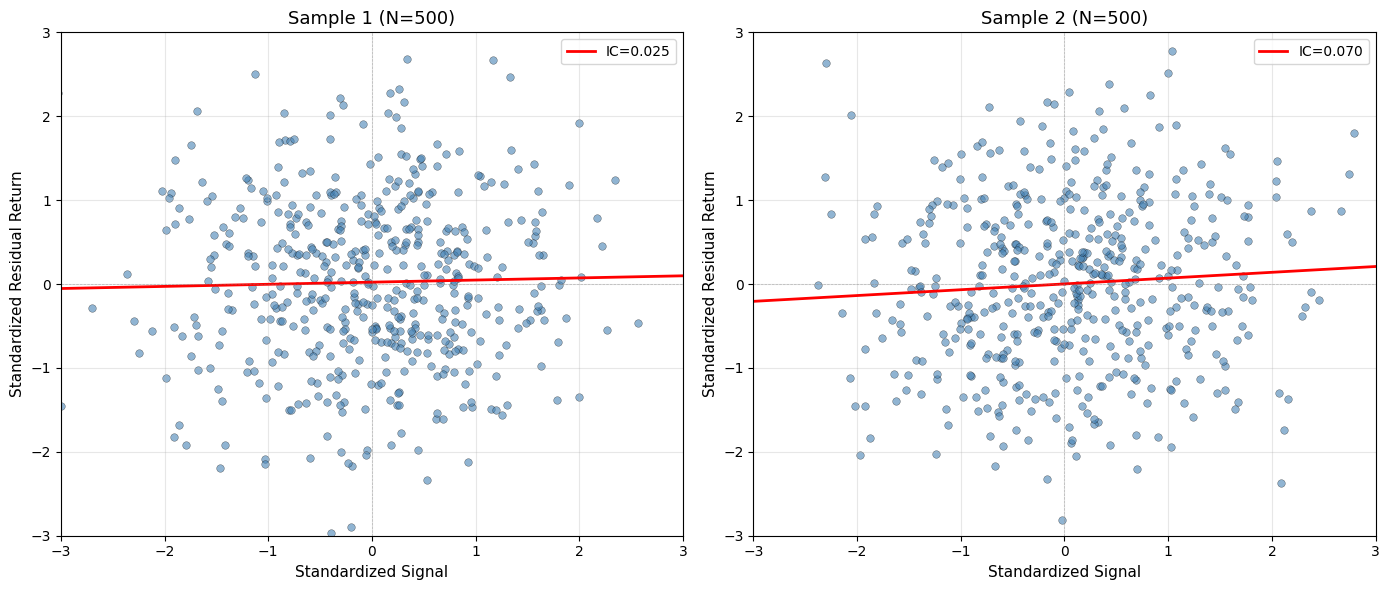

In [ ]:
# IC=0.05程度のシグナルと残差リターンの関係を可視化

np.random.seed(42)
n_stocks = 500  # クロスセクションの銘柄数
target_ic = 0.05  # 目標IC

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左図：サンプル1
mean = [0, 0]
cov = [[1, target_ic], [target_ic, 1]]
samples_1 = np.random.multivariate_normal(mean, cov, n_stocks)
signal_1 = samples_1[:, 0]
return_1 = samples_1[:, 1]
ic_1 = np.corrcoef(signal_1, return_1)[0, 1]

axes[0].scatter(
    signal_1,
    return_1,
    alpha=0.6,
    s=30,
    color="steelblue",
    edgecolor="black",
    linewidth=0.3,
)

# 回帰線
from sklearn.linear_model import LinearRegression

reg_1 = LinearRegression().fit(signal_1.reshape(-1, 1), return_1)
x_line = np.linspace(-3, 3, 100)
y_line = reg_1.predict(x_line.reshape(-1, 1))
axes[0].plot(x_line, y_line, "r-", linewidth=2, label=f"IC={ic_1:.3f}")

axes[0].axhline(y=0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].axvline(x=0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].set_xlabel("Standardized Signal", fontsize=11)
axes[0].set_ylabel("Standardized Residual Return", fontsize=11)
axes[0].set_title(f"Sample 1 (N={n_stocks})", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)

# 右図：サンプル2（異なるランダムシード）
np.random.seed(123)
samples_2 = np.random.multivariate_normal(mean, cov, n_stocks)
signal_2 = samples_2[:, 0]
return_2 = samples_2[:, 1]
ic_2 = np.corrcoef(signal_2, return_2)[0, 1]

axes[1].scatter(
    signal_2,
    return_2,
    alpha=0.6,
    s=30,
    color="steelblue",
    edgecolor="black",
    linewidth=0.3,
)

# 回帰線
reg_2 = LinearRegression().fit(signal_2.reshape(-1, 1), return_2)
y_line = reg_2.predict(x_line.reshape(-1, 1))
axes[1].plot(x_line, y_line, "r-", linewidth=2, label=f"IC={ic_2:.3f}")

axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
axes[1].axvline(x=0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
axes[1].set_xlabel("Standardized Signal", fontsize=11)
axes[1].set_ylabel("Standardized Residual Return", fontsize=11)
axes[1].set_title(f"Sample 2 (N={n_stocks})", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

### 3.3 実データによるIC計算例

ここでは、Section 1.1で計算した残差リターンを用いて、短期リバーサルファクターのICを計算します。

**ファクター定義**（Alpha101 [3] より）：
$$
\text{Reversal}_{i;t} = -\frac{\text{Close}_{i;t} - \text{Open}_{i;t}}{\text{High}_{i;t} - \text{Low}_{i;t}}
$$

このファクターは、日中の値動き（Close - Open）を日中レンジ（High - Low）で正規化し、符号を反転させたものです。World Quantが論文で提案した基礎的なアルファファクターの一つであり、短期的な価格反転（リバーサル）効果を捉えることを目的としています。

In [ ]:
# 短期リバーサルファクターの計算
# 1.1節で作成したdata_mergedを使用

# 短期リバーサルファクター（調整済み価格を使用）:
# -(AdjustmentClose - AdjustmentOpen) / (AdjustmentHigh - AdjustmentLow)
data_merged["intraday_range"] = (
    data_merged["AdjustmentHigh"] - data_merged["AdjustmentLow"]
)
data_merged["intraday_change"] = (
    data_merged["AdjustmentClose"] - data_merged["AdjustmentOpen"]
)

# ゼロ除算を避ける
min_range = 1e-6
data_merged.loc[data_merged["intraday_range"] < min_range, "intraday_range"] = min_range
data_merged["reversal_factor"] = -(
    data_merged["intraday_change"] / data_merged["intraday_range"]
)

# シグナルまたはリターンを計算できない行を除去
data_clean = data_merged.dropna(subset=["residual_return", "reversal_factor"])

print(f"クリーニング後: {data_clean.shape}")
print(f"\nファクター統計:")
print(data_clean["reversal_factor"].describe())

NameError: name 'data_merged' is not defined

In [ ]:
# 日次IC・RICの計算
ic_results = []

for date, group in data_clean.groupby("Date"):
    if len(group) < 5:
        continue

    signal = group["reversal_factor"].values
    returns = group["residual_return"].values

    mask = ~(np.isnan(signal) | np.isnan(returns))
    if mask.sum() < 5:
        continue

    # IC: Pearson相関（線形関係）
    ic = np.corrcoef(signal[mask], returns[mask])[0, 1]

    # RIC: Spearman順位相関（単調関係）
    ric, _ = stats.spearmanr(signal[mask], returns[mask])

    ic_results.append({"Date": date, "ic": ic, "ric": ric, "n_stocks": mask.sum()})

ic_df = pd.DataFrame(ic_results)

# IC統計
print("=" * 70)
print("IC・RIC統計サマリー")
print("=" * 70)
print(f"\n【IC（Pearson相関）】")
print(f"平均IC: {ic_df['ic'].mean():.4f}")
print(f"IC標準偏差: {ic_df['ic'].std():.4f}")
print(f"IC t値: {ic_df['ic'].mean() / (ic_df['ic'].std() / np.sqrt(len(ic_df))):.2f}")
print(f"正のICの割合: {(ic_df['ic'] > 0).sum() / len(ic_df) * 100:.1f}%")
print(
    f"|IC| > 0.05の割合: {(np.abs(ic_df['ic']) > 0.05).sum() / len(ic_df) * 100:.1f}%"
)

print(f"\n【RIC（Spearman順位相関）】")
print(f"平均RIC: {ic_df['ric'].mean():.4f}")
print(f"RIC標準偏差: {ic_df['ric'].std():.4f}")
print(
    f"RIC t値: {ic_df['ric'].mean() / (ic_df['ric'].std() / np.sqrt(len(ic_df))):.2f}"
)
print(f"正のRICの割合: {(ic_df['ric'] > 0).sum() / len(ic_df) * 100:.1f}%")
print(
    f"|RIC| > 0.05の割合: {(np.abs(ic_df['ric']) > 0.05).sum() / len(ic_df) * 100:.1f}%"
)

In [ ]:
# IC・RIC時系列の可視化
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. IC時系列
axes[0, 0].plot(
    ic_df["Date"],
    ic_df["ic"],
    alpha=0.6,
    linewidth=0.8,
    color="blue",
    label="IC (Pearson)",
)
axes[0, 0].axhline(y=0, color="black", linestyle="--", linewidth=0.5)
axes[0, 0].axhline(
    y=ic_df["ic"].mean(),
    color="red",
    linestyle="-",
    linewidth=1.5,
    label=f"Mean={ic_df['ic'].mean():.4f}",
)
axes[0, 0].axhline(y=0.05, color="green", linestyle=":", alpha=0.5)
axes[0, 0].axhline(y=-0.05, color="green", linestyle=":", alpha=0.5)
axes[0, 0].set_ylabel("IC")
axes[0, 0].set_title("IC over Time (Pearson Correlation)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. RICの時系列
axes[0, 1].plot(
    ic_df["Date"],
    ic_df["ric"],
    alpha=0.6,
    linewidth=0.8,
    color="orange",
    label="RIC (Spearman)",
)
axes[0, 1].axhline(y=0, color="black", linestyle="--", linewidth=0.5)
axes[0, 1].axhline(
    y=ic_df["ric"].mean(),
    color="red",
    linestyle="-",
    linewidth=1.5,
    label=f"Mean={ic_df['ric'].mean():.4f}",
)
axes[0, 1].axhline(y=0.05, color="green", linestyle=":", alpha=0.5)
axes[0, 1].axhline(y=-0.05, color="green", linestyle=":", alpha=0.5)
axes[0, 1].set_ylabel("RIC")
axes[0, 1].set_title("RIC over Time (Spearman Rank Correlation)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ICとRICの散布図
axes[1, 0].scatter(ic_df["ic"], ic_df["ric"], alpha=0.3, s=10, color="purple")
axes[1, 0].plot([-1, 1], [-1, 1], "r--", linewidth=1, alpha=0.5, label="IC=RIC")
axes[1, 0].set_xlabel("IC (Pearson)")
axes[1, 0].set_ylabel("RIC (Spearman)")
axes[1, 0].set_title(f"IC vs RIC (Correlation={ic_df['ic'].corr(ic_df['ric']):.3f})")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-0.5, 0.5)
axes[1, 0].set_ylim(-0.5, 0.5)

# 4. IC・RICの累積値
axes[1, 1].plot(
    ic_df["Date"],
    ic_df["ic"].cumsum(),
    color="blue",
    linewidth=1.5,
    label="Cumulative IC",
    alpha=0.7,
)
axes[1, 1].plot(
    ic_df["Date"],
    ic_df["ric"].cumsum(),
    color="orange",
    linewidth=1.5,
    label="Cumulative RIC",
    alpha=0.7,
)
axes[1, 1].set_ylabel("Cumulative Value")
axes[1, 1].set_title("Cumulative IC and RIC")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. IC分布
axes[2, 0].hist(
    ic_df["ic"], bins=50, alpha=0.7, color="blue", edgecolor="black", label="IC"
)
axes[2, 0].axvline(x=0, color="black", linestyle="--", linewidth=1)
axes[2, 0].axvline(x=ic_df["ic"].mean(), color="red", linestyle="-", linewidth=2)
axes[2, 0].set_xlabel("IC")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].set_title("IC Distribution")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. RICの分布
axes[2, 1].hist(
    ic_df["ric"], bins=50, alpha=0.7, color="orange", edgecolor="black", label="RIC"
)
axes[2, 1].axvline(x=0, color="black", linestyle="--", linewidth=1)
axes[2, 1].axvline(x=ic_df["ric"].mean(), color="red", linestyle="-", linewidth=2)
axes[2, 1].set_xlabel("RIC")
axes[2, 1].set_ylabel("Frequency")
axes[2, 1].set_title("RIC Distribution")
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**ICの時変性**

- シグナルの効き方は時期によって異なります。過去時点でのパターンを未来時点でも再現しようとするならば、なぜそのシグナルが効くのかについての構造的・因果的理解が肝要です。
- なお短期リバーサルが日本株大型株にて過去有効であった要因として日銀によるETF買い入れ(~2024/03にて新規買入停止)によって生じたフローの歪みが挙げられます。

## 4. Information Ratio (IR)

Information Ratioは、アクティブ運用のリスク調整後パフォーマンスを測る指標です。


### 4.1 IRの定義

Information Ratio（IR）は、ポートフォリオのリスク調整後パフォーマンスを残差ベースで評価する指標です：

$$
\text{IR}_t \mathrel{:=} \frac{\mathbb{E}[r_A]}{\sigma (r_A)} =
\frac{\boldsymbol{w}_t^\top \boldsymbol{\alpha}_t}{\sqrt{\boldsymbol{w}_t^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w}_t}}
$$

ここで、
- $r_A$: アクティブリターン（ポートフォリオリターン $r_p$ - ベンチマークリターン $r_M$）
- $\mathbb{E}[r_A]$: アクティブリターンの期待値
- $\sigma(r_A)$: アクティブリターンの標準偏差（tracking error）
- $\boldsymbol{w}_t$: 時刻 $t$ におけるポートフォリオのアクティブウェイトベクトル（$N$ 次元）
- $\boldsymbol{\alpha}_t$: 各銘柄のアルファベクトル $[\alpha_{1,t}, \alpha_{2,t}, \ldots, \alpha_{N,t}]^\top$
- $\boldsymbol{\Sigma}^{\mathrm{res}}_t$: 残差リターンの条件付き共分散行列（$N \times N$）

分子 $\boldsymbol{w}_t^\top \boldsymbol{\alpha}_t$ はポートフォリオの期待アクティブリターン、分母 $\sqrt{\boldsymbol{w}_t^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w}_t}$ はアクティブリスク（トラッキングエラー）を表します。

IRは「単位アクティブリスクあたりのアクティブリターン」を表し、アクティブ運用の効率性を測る最も重要な指標です。

**IRの実務的基準**：
- **IR ≥ 1.0**: 優れたアクティブ運用

IRはSharpe Ratioのアクティブ運用版と考えることができ、ベンチマークに対する相対パフォーマンスを評価します。
今回の講義ではベンチマークリターンを市場リターン$r_M$として話を進めます(がその限りではありません)。


## 5. IRとICの関係：アクティブ運用の基本定理

Grinold-Kahnによる**アクティブ運用の基本定理**は、IRとICの関係を明確にする重要な結果です。


### 5.1 基本定理

アクティブ運用の情報レシオ（IR）は、予測の精度を表すICと、独立した投資機会の数を表すBreadth（BR）によって、次のように近似されます。

$$
\mathrm{IR} \approx \mathrm{IC}\sqrt{\mathrm{BR}}
$$

この式は、予測精度が同じでも、独立した投資機会を増やすことでIRを高められることを示しています。ただし、効果はBRそのものではなく平方根に比例するため、機会を増やすほど改善幅は逓減します。  

運用上の制約を考慮する場合は、予測をポートフォリオへ反映できる度合いを表すTransfer Coefficient（TC）を加えます。

$$
\mathrm{IR} \approx \mathrm{IC}\sqrt{\mathrm{BR}}\,\mathrm{TC}
$$

導出と各項目の詳しい解釈は、末尾の「数式の補足」に示します。


## 6. バックテストと評価指標

アクティブ運用戦略を評価するためには、適切なバックテストと評価指標が不可欠です。


### 6.1 主要な評価指標

#### Sharpe Ratio（シャープレシオ）

$$
\text{Sharpe Ratio} = \frac{\mathbb{E}[r_p - r_f]}{\sigma(r_p)}
$$

- $r_p$: ポートフォリオリターン
- $r_f$: 無リスク金利
- リスク調整後リターンを測る最も一般的な指標

#### Maximum Drawdown（最大ドローダウン）

$$
\text{MDD} = \max_{t} \left[\left[ \max_{s \leq t} V_s - V_t \right] / \max_{s \leq t} V_s \right]
$$

- 過去のピークからの最大下落率
- リスク管理上、非常に重要な指標

#### Calmar Ratio

$$
\text{Calmar Ratio} = \frac{\text{年率リターン}}{\text{最大ドローダウン}}
$$

- リターンをドローダウンリスクで割った比率
- 長期投資家にとって重要な指標

#### Sortino Ratio

$$
\text{Sortino Ratio} = \frac{\mathbb{E}[r_p - r_f]}{\sigma_{\text{downside}}(r_p)}
$$

- 下方リスク（マイナスのリターンの変動）のみを考慮
- 上振れを罰しない、より洗練された指標


In [ ]:
# 評価指標の計算関数


def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
    """
    シャープレシオを計算（年率換算）
    """
    excess_returns = returns - risk_free_rate
    sharpe = np.mean(excess_returns) / np.std(excess_returns, ddof=1)
    return sharpe * np.sqrt(ANNUAL_DAYS)  # 日次データを年率換算


def calculate_ir(residual_returns):
    """
    情報レシオを計算（年率換算）
    IR = mean(residual_returns) / std(residual_returns) * sqrt(ANNUAL_DAYS)
    """
    if len(residual_returns) == 0:
        return 0.0
    mean_return = np.mean(residual_returns)
    std_return = np.std(residual_returns, ddof=1)
    if std_return == 0:
        return 0.0 if mean_return == 0 else np.inf
    ir = mean_return / std_return
    return ir * np.sqrt(ANNUAL_DAYS)  # 日次データを年率換算


def calculate_max_drawdown(cumulative_returns):
    """
    最大ドローダウンを計算
    """
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    max_dd = np.min(drawdown)
    return max_dd


def calculate_calmar_ratio(returns, cumulative_returns):
    """
    カルマーレシオを計算
    """
    annual_return = np.mean(returns) * ANNUAL_DAYS
    max_dd = abs(calculate_max_drawdown(cumulative_returns))
    if max_dd == 0:
        return np.inf
    return annual_return / max_dd


def calculate_sortino_ratio(returns, risk_free_rate=0.0, target_return=0.0):
    """
    ソルティノレシオを計算
    """
    excess_returns = returns - risk_free_rate
    downside_returns = excess_returns[excess_returns < target_return]
    if len(downside_returns) == 0:
        return np.inf
    downside_std = np.std(downside_returns, ddof=1)
    if downside_std == 0:
        return np.inf
    sortino = np.mean(excess_returns) / downside_std
    return sortino * np.sqrt(ANNUAL_DAYS)  # 年率換算

### 6.2 実践例：リバーサルファクターによるL/S戦略

ここでは、Section 3.3で計算した短期リバーサルファクターを用いたロング・ショート戦略のバックテストを実施し、上記の評価指標を実際に計算します。

**戦略概要**：
- 各日において、リバーサルファクターで銘柄をランキング
- 上位N=20銘柄をロング（equal weight）
- 下位N=20銘柄をショート（equal weight）
- 翌日のOpen-to-Openリターンで評価
- ポートフォリオはドルニュートラル（ロング50%、ショート50%）

**注意**
- 本来は取引コスト(手数料・持ち越し金利)および発注単元(日本株は100株ずつのみしか発注できない)を考慮する必要があります。
- あくまで簡易的な検証にすぎません。

In [ ]:
# L/S戦略のバックテスト（ウェイトベース）
N = 20  # 上位・下位それぞれの銘柄数

portfolio_returns_residual = []  # IR計算用（残差リターン）
portfolio_returns_total = []  # SR計算用（トータルリターン）
portfolio_dates = []
portfolio_weights_history = {}  # 各日付のウェイト辞書を保存（取引コスト計算で使用）

for date, group in data_clean.groupby("Date"):
    # リバーサルファクターでソート（降順 = 高い値が上位）
    sorted_group = group.sort_values("reversal_factor", ascending=False)

    # 上位N銘柄をロング、下位N銘柄をショート
    long_stocks = sorted_group.head(N)
    short_stocks = sorted_group.tail(N)

    # 当日のウェイトを計算
    curr_weights = {}

    # ロング側: +1/(2N) ずつ
    for code in long_stocks["Code"].values:
        curr_weights[code] = 1.0 / (2 * N)

    # ショート側: -1/(2N) ずつ
    for code in short_stocks["Code"].values:
        curr_weights[code] = -1.0 / (2 * N)

    # ウェイトを保存（取引コスト計算で使用）
    portfolio_weights_history[date] = curr_weights

    # ポートフォリオのリターンを計算（ウェイト × リターン）
    long_residual = (long_stocks["residual_return"] * (1.0 / (2 * N))).sum()
    short_residual = (short_stocks["residual_return"] * (-1.0 / (2 * N))).sum()
    portfolio_return_residual = long_residual + short_residual

    long_total = (long_stocks["stock_return"] * (1.0 / (2 * N))).sum()
    short_total = (short_stocks["stock_return"] * (-1.0 / (2 * N))).sum()
    portfolio_return_total = long_total + short_total

    portfolio_returns_residual.append(portfolio_return_residual)
    portfolio_returns_total.append(portfolio_return_total)
    portfolio_dates.append(date)

# 日次ポートフォリオ損益を表形式にまとめる
portfolio_df = pd.DataFrame(
    {
        "Date": portfolio_dates,
        "Return_Residual": portfolio_returns_residual,
        "Return_Total": portfolio_returns_total,
    }
)

# 累積リターンを計算
portfolio_df["Cumulative_Residual"] = (1 + portfolio_df["Return_Residual"]).cumprod()
portfolio_df["Cumulative_Total"] = (1 + portfolio_df["Return_Total"]).cumprod()

# パフォーマンス指標を計算
sr_ls = calculate_sharpe_ratio(portfolio_df["Return_Total"].values)
ir_ls = calculate_ir(portfolio_df["Return_Residual"].values)

print("\n" + "=" * 80)
print("L/S戦略（短期リバーサル、N=20銘柄ずつ）のパフォーマンス")
print("=" * 80)

# トータルリターンからシャープレシオを計算
print("\n【トータルリターン（元のリターン）】")
print(f"年率リターン: {portfolio_df['Return_Total'].mean() * ANNUAL_DAYS * 100:.2f}%")
print(
    f"年率ボラティリティ: {portfolio_df['Return_Total'].std() * np.sqrt(ANNUAL_DAYS) * 100:.2f}%"
)
print(f"シャープレシオ: {sr_ls:.3f}")

# 残差リターンから情報レシオを計算
print("\n【残差リターン（市場調整後）】")
print(
    f"年率リターン: {portfolio_df['Return_Residual'].mean() * ANNUAL_DAYS * 100:.2f}%"
)
print(
    f"年率ボラティリティ: {portfolio_df['Return_Residual'].std() * np.sqrt(ANNUAL_DAYS) * 100:.2f}%"
)
print(f"情報レシオ: {ir_ls:.3f}")

print("\n ウェイト履歴を保存しました（取引コスト計算で使用）")
print(f"   - 日数: {len(portfolio_weights_history)}日")
print(
    f"   - 各日のウェイト: ロング{N}銘柄（1銘柄当たり+{1 / (2 * N):.4f}）、ショート{N}銘柄（1銘柄当たり-{1 / (2 * N):.4f}）"
)

print("=" * 80)

In [ ]:
# バックテスト結果の可視化
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 累積リターン（トータル vs 残差）
axes[0, 0].plot(
    portfolio_df["Date"],
    portfolio_df["Cumulative_Total"],
    linewidth=2,
    color="darkblue",
    label="Total Return",
    alpha=0.8,
)
axes[0, 0].plot(
    portfolio_df["Date"],
    portfolio_df["Cumulative_Residual"],
    linewidth=2,
    color="green",
    label="Residual Return",
    alpha=0.8,
    linestyle="--",
)
axes[0, 0].axhline(y=1, color="black", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0, 0].set_ylabel("Cumulative Return")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_title("Cumulative Return: Total vs Residual")
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# 2. ドローダウン（トータルリターン）
running_max_ls = np.maximum.accumulate(portfolio_df["Cumulative_Total"].values)
drawdown_ls = (
    portfolio_df["Cumulative_Total"].values - running_max_ls
) / running_max_ls
max_dd_ls = drawdown_ls.min()

axes[0, 1].fill_between(
    portfolio_df["Date"], drawdown_ls * 100, 0, color="red", alpha=0.3
)
axes[0, 1].axhline(
    y=max_dd_ls * 100,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Max DD = {max_dd_ls * 100:.2f}%",
)
axes[0, 1].set_ylabel("Drawdown (%)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_title("Drawdown: Total Return")
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha="right")

# 3. リターン分布の比較
axes[1, 0].hist(
    portfolio_df["Return_Total"] * 100,
    bins=50,
    alpha=0.5,
    color="blue",
    edgecolor="black",
    label="Total",
)
axes[1, 0].hist(
    portfolio_df["Return_Residual"] * 100,
    bins=50,
    alpha=0.5,
    color="green",
    edgecolor="black",
    label="Residual",
)
axes[1, 0].axvline(x=0, color="black", linestyle="--", linewidth=1)
axes[1, 0].axvline(
    x=portfolio_df["Return_Total"].mean() * 100,
    color="blue",
    linestyle="-",
    linewidth=2,
)
axes[1, 0].axvline(
    x=portfolio_df["Return_Residual"].mean() * 100,
    color="green",
    linestyle="-",
    linewidth=2,
)
axes[1, 0].set_xlabel("Daily Return (%)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Daily Return Distribution: Total vs Residual")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ローリングSR・IR (60日)
window = 60
rolling_sr_ls = []
rolling_ir_ls = []
rolling_dates = []

for i in range(window, len(portfolio_df)):
    # トータルリターンのシャープレシオ
    window_returns_total = portfolio_df["Return_Total"].iloc[i - window : i].values
    sr_i = calculate_sharpe_ratio(window_returns_total)
    rolling_sr_ls.append(sr_i)

    # 残差リターンの情報レシオ
    window_returns_residual = (
        portfolio_df["Return_Residual"].iloc[i - window : i].values
    )
    ir_i = calculate_ir(window_returns_residual)
    rolling_ir_ls.append(ir_i)

    rolling_dates.append(portfolio_df["Date"].iloc[i])

axes[1, 1].plot(
    rolling_dates,
    rolling_sr_ls,
    linewidth=1.5,
    color="blue",
    label=f"SR (Mean={sr_ls:.2f})",
    alpha=0.7,
)
axes[1, 1].plot(
    rolling_dates,
    rolling_ir_ls,
    linewidth=1.5,
    color="green",
    label=f"IR (Mean={ir_ls:.2f})",
    alpha=0.7,
)
axes[1, 1].axhline(y=sr_ls, color="blue", linestyle="--", linewidth=1, alpha=0.5)
axes[1, 1].axhline(y=ir_ls, color="green", linestyle="--", linewidth=1, alpha=0.5)
axes[1, 1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Sharpe / Information Ratio")
axes[1, 1].set_title(f"Rolling SR and IR ({window} Days)")
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

左上では、残差リターンの累積がトータルリターンを上回っており、市場要因を除いた銘柄選択部分がプラスに働いていたことが分かります。ただし、残差リターンは診断用の値であり、実際に得られる投資成果そのものではありません。

右上のドローダウンからは、累積リターンが上昇している期間でも一時的な下落が発生していることが分かります。左下の分布と右下のローリングSR・IRを見ると、日々の損益や戦略の有効性には時期によってばらつきがあります。

## 7. 取引コストとターンオーバー

### 7.1 取引コストとターンオーバーの関係

#### ターンオーバー（Turnover）の定義

時刻$t$におけるポートフォリオのターンオーバーは、ポジション変化の絶対値として定義されます：

$$
TO_t = \sum_{i=1}^{N} |w_{i;t} - w_{i;t-1}|
$$

ここで：
- $w_{i;t}$: 時刻$t$における銘柄$i$のウェイト
- $N$: ポートフォリオ内の銘柄数
- $|\cdot|$: 絶対値（ロングもショートも両方カウント）

**L/S戦略の場合：**
- ロング側とショート側の両方でポジション変更が発生
- 例：各銘柄に資金等配分で20銘柄をロング、20銘柄をショート → 各銘柄のウェイト = $\frac{1}{40}$ = 2.5%

#### 取引コストの定義

時刻$t$における取引コストは、片道コスト$c$とターンオーバー$TO_t$の積として表されます：

$$
\text{Cost}_t = c \times TO_t
$$

ここで、$c$は**片道コスト**（one-way transaction cost）で、以下の要素を含みます：

$$
c = c_{\text{spread}} + c_{\text{impact}} + c_{\text{commission}}
$$

- $c_{\text{spread}}$: ビッド・アスク・スプレッド
- $c_{\text{impact}}$: マーケット・インパクト
- $c_{\text{commission}}$: 手数料

これらのコストは銘柄ごとの流動性や投入資金額によっても変動します。
論文などでは市場にもよりますが$c=5bps$などとして評価していることが多いです。

#### コスト控除後リターン

取引コストを考慮したネット・リターンは：

$$
r_{t}^{\text{net}} = r_t - c \times TO_t
$$

ここで：
- $r_t$: グロス・リターン（コスト前）
- $r_{t}^{\text{net}}$: ネット・リターン（コスト後）


### 実際の計算例
**6.2で定義した短期リバーサル戦略の実際のターンオーバーと取引コストを計算します。**

#### 本戦略の具体的なコスト算出

セクション6.2で実装したL/S戦略（N=20銘柄ずつ）について、
実際のターンオーバーと取引コストを算出します。

In [ ]:
# TOの計算（セクション6.2で計算したウェイトを使用）
# TO_t = Σ|w_{i,t} - w_{i,t-1}|

# セクション6.2で計算・保存したウェイト履歴を使用
if "portfolio_weights_history" not in globals():
    raise ValueError(
        "portfolio_weights_history が見つかりません。先にセクション6.2のL/Sバックテストを実行してください。"
    )

turnover_data = []
dates = sorted(portfolio_weights_history.keys())

for idx, date in enumerate(dates):
    curr_weights = portfolio_weights_history[date]

    if idx == 0:
        # 初日は全ポジション構築
        turnover = sum(abs(w) for w in curr_weights.values())
    else:
        # 前日のウェイトを取得
        prev_date = dates[idx - 1]
        prev_weights = portfolio_weights_history[prev_date]

        # TO = Σ|w_{i,t} - w_{i,t-1}|
        # 全銘柄のウェイト変化を計算
        all_codes = set(curr_weights.keys()) | set(prev_weights.keys())
        turnover = 0.0
        for code in all_codes:
            w_curr = curr_weights.get(code, 0.0)
            w_prev = prev_weights.get(code, 0.0)
            turnover += abs(w_curr - w_prev)

    turnover_data.append({"Date": date, "Turnover": turnover})

turnover_df = pd.DataFrame(turnover_data)

# 統計量
avg_turnover = turnover_df["Turnover"].mean()
median_turnover = turnover_df["Turnover"].median()
max_turnover = turnover_df["Turnover"].max()
min_turnover = turnover_df["Turnover"].min()

print("\n" + "=" * 80)
print("短期リバーサル戦略のTO統計（実測値）")
print("=" * 80)
print(f"平均日次TO: {avg_turnover:.3f} ({avg_turnover * 100:.1f}%)")
print(f"中央値TO:   {median_turnover:.3f} ({median_turnover * 100:.1f}%)")
print(f"最大TO:     {max_turnover:.3f} ({max_turnover * 100:.1f}%)")
print(f"最小TO:     {min_turnover:.3f} ({min_turnover * 100:.1f}%)")
print(
    f"\n年間TO: {avg_turnover * ANNUAL_DAYS:.1f} = {avg_turnover * ANNUAL_DAYS * 100:.0f}%"
)
print("\n 計算方法：")
print(f"   - セクション6.2で計算したウェイト履歴を使用")
print(f"   - TO_t = Σ|w_{{i,t}} - w_{{i,t-1}}|")
print(
    f"   - ロング銘柄: +{1 / (2 * 20):.4f}, ショート銘柄: -{1 / (2 * 20):.4f}, その他: 0.0"
)
print("=" * 80)

In [ ]:
# 取引コスト計算（片道コスト c = 5 bps）

# 片道コスト
one_way_cost_bps = 5.0
one_way_cost = one_way_cost_bps * 1e-4  # 5 bps = 0.0005

print("\n" + "=" * 80)
print("短期リバーサル戦略の取引コスト分析")
print("=" * 80)
print(f"\n【前提条件】")
print(f"  - 片道コスト: c = {one_way_cost_bps:.0f} bps")
print(f"  - 平均日次ターンオーバー: {avg_turnover:.3f} ({avg_turnover * 100:.1f}%)")
print(f"  - 年間営業日数: {ANNUAL_DAYS}日")

# 日次コストは片道コスト率とターンオーバーの積
daily_cost = one_way_cost * avg_turnover
annual_cost = daily_cost * ANNUAL_DAYS

print("\n" + "-" * 80)
print("【取引コスト】")
print("-" * 80)
print(f"平均日次コスト: {daily_cost * 100:.4f}% = {daily_cost * 1e4:.2f} bps")
print(f"年間コスト:   {annual_cost * 100:.2f}%")
print(
    f"\n計算式: 日次コスト = 片道コスト率 × ターンオーバー = {one_way_cost_bps} bps × {avg_turnover:.3f} = {daily_cost * 1e4:.2f} bps/日"
)

# 戦略パフォーマンスとの比較
gross_annual_return = portfolio_df["Return_Total"].mean() * ANNUAL_DAYS
net_annual_return = gross_annual_return - annual_cost

print("\n" + "=" * 80)
print("【戦略パフォーマンス（コスト前後の比較）】")
print("=" * 80)
print(f"\nグロス年率リターン（コスト前）: {gross_annual_return * 100:>7.2f}%")
print(f"年間取引コスト:                   {annual_cost * 100:>7.2f}%")
print(f"{'=' * 40}")
print(f"ネット年率リターン（コスト後）:   {net_annual_return * 100:>7.2f}%")


print("\n" + "=" * 80)

**結果の解釈**
- 短期リバーサル戦略は日次での頻繁なドテン売買(保持していたポジション方向を反転させること)を余儀なくされ取引コストが嵩んでいる。
- シグナル単体では有効に見えていてもポートフォリオ運用がうまくいくわけではない一例。
    - (=売買代金の大きい機関投資家が狙えないリターン)

**TOを抑制できる有効なシグナルを設計することが好ましいことがわかります。**
- 以下でTOを抑制するためのロバストなポートフォリオ設計方法の一例について述べます

### 7.2 TO抑制のための実務的工夫

ロバストなポートフォリオ（シグナル）設計のために<strong>分位ポートフォリオ（Quantile Portfolio）</strong>と<strong>順位正規化（Rank Normalization）</strong>は重要な概念です。

#### 分位ポートフォリオとは？

分位ポートフォリオは、何らかの<strong>シグナル（予測値、ファクター値など）</strong>に基づいて銘柄を<strong>分位（グループ）</strong>に分け、各分位に等ウェイトで投資する手法です。

##### 基本的な手順

1. 全銘柄にシグナル値を計算（例: 12-1モメンタム）
2. シグナル値でランク付け
3. N個の分位（グループ）に分割（例: 5分位なら上位20%、次の20%、...）
4. 各分位内で等ウェイト投資

##### 分位化の目的

**1. ノイズの影響を減らす**

金融データのノイジーな特性によりシグナルも同様にノイジーになり得ます。

- **連続値を使う場合**:
  - シグナル: [0.05, 0.048, 0.046, -0.04, -0.042]
  - ウェイト: そのままシグナルに比例
  - 問題: 0.05と0.048の差は本当に意味があるか？ノイズかもしれません
  
- **分位化する場合**:
  - 上位N%ロング、下位M%ショートとするなど
  - 細かいランク差は無視され、よりロバストなウェイト設計になります。

**2. 外れ値の影響を抑える**

極端な予測値の影響を制限できます。

- **例**: シグナルが[-0.5, -0.1, 0.0, 0.1, 10.0]の場合
  - 連続値: 10.0が支配的になってしまう
  - 分位化: 10.0も「上位20%」として同じ扱い

**3. 解釈しやすい**

散布図ではシグナルとターゲットとの関係がノイジーに見えるが分位ごとの関係性を見ることで関係性が見やすくなります。

- Q1（下位20%）vs Q5（上位20%）のパフォーマンス差を見れば、シグナルの有効性が分かる
- ロング・ショート戦略: Q5をロング、Q1をショート

#### 順位正規化（Rank Normalization）

順位正規化とは、シグナルの順位に基づいてシグナルの連続値を正規分布へと再変換する操作を指します。

##### 手順

1. **予測値を順位に変換**:
   - N個の予測値を1位、2位、...、N位にランク付け
   - これを0〜1の範囲に正規化: $(\mathrm{rank}- 1) / (N - 1)$

2. **正規分布の分位点関数で変換**:
   - 標準正規分布 $N(0, 1)$ の分位点関数（逆CDF）を適用
   - $z = \Phi^{-1}(p)$ ここで $p$ は順位パーセンタイル
   - 結果: 平均0、標準偏差1の正規分布に従うシグナル

##### メリット

1. **外れ値の影響を完全に排除**: 極端な予測値も±3σ程度に収まる
2. **異なるモデルの予測値を比較可能**: スケールが統一されます
3. **アンサンブルしやすい**: 複数モデルの予測を平均する際に便利
4. **安定性**: 予測値の分布がデータによって変わりません

これらを特徴量評価やポートフォリオ構築の際に組み合わせることでノイズや市況変化に比較的ロバストな戦略構築が達成できるかもしれません。

#### 7.2.1 実例：短期リバーサルシグナルでの5分位分析

Section 3.3で計算した短期リバーサルシグナルを使って**5分位ポートフォリオ**の実例を示します。

**分位ポートフォリオの構築**：
1. 各日において、リバーサルファクターで銘柄をランキング
2. 5分位（Q1〜Q5）に分割
   - Q1: 下位20%
   - Q5: 上位20%
3. 各分位内で等ウェイト投資
4. 翌日の残差リターンを測定

In [ ]:
# 5分位ポートフォリオの構築と評価（短期リバーサルシグナル）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 市場調整済みの残差リターンと、市場リスクを含む実リターンを併記

# 各日付で5分位に分割し、両方のリターンを集計
quintile_returns_residual = {f"Q{i}": [] for i in range(1, 6)}
quintile_returns_total = {f"Q{i}": [] for i in range(1, 6)}
dates = []  # 日付を保持

for date, group in data_clean.groupby("Date"):
    dates.append(date)
    # リバーサルファクターでランキング（昇順 = 低い方が下位）
    group = group.sort_values("reversal_factor", ascending=True)

    # 5分位に分割
    group["quintile"] = pd.qcut(
        group["reversal_factor"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]
    )

    # 各分位の平均リターンを記録
    for q in range(1, 6):
        q_stocks = group[group["quintile"] == q]
        if len(q_stocks) > 0:
            # 残差リターンと実際のリターン両方を記録
            quintile_returns_residual[f"Q{q}"].append(
                q_stocks["residual_return"].mean()
            )
            quintile_returns_total[f"Q{q}"].append(q_stocks["stock_return"].mean())

# 分位別の日次リターンを表形式にまとめ、日付をインデックスにする
quintile_df_residual = pd.DataFrame(quintile_returns_residual, index=dates)
quintile_df_total = pd.DataFrame(quintile_returns_total, index=dates)

# 統計量を計算
print("=" * 80)
print("短期リバーサルシグナル：5分位ポートフォリオの統計量")
print("=" * 80)
print("\n【残差リターン（residual_return：市場調整済み）】")
print("各分位の年率リターンとシャープレシオ:")
for q in range(1, 6):
    mean_ret = quintile_df_residual[f"Q{q}"].mean() * 252
    std_ret = quintile_df_residual[f"Q{q}"].std() * np.sqrt(252)
    sharpe = (
        quintile_df_residual[f"Q{q}"].mean()
        / quintile_df_residual[f"Q{q}"].std()
        * np.sqrt(252)
    )
    print(
        f"  Q{q}: 年率 {mean_ret:7.4f} ({mean_ret * 100:6.2f}%)  ボラ {std_ret:6.4f}  SR {sharpe:6.3f}"
    )

print("\n【実際のリターン（stock_return：市場リスク込み）】")
print("各分位の年率リターンとシャープレシオ:")
for q in range(1, 6):
    mean_ret = quintile_df_total[f"Q{q}"].mean() * 252
    std_ret = quintile_df_total[f"Q{q}"].std() * np.sqrt(252)
    sharpe = (
        quintile_df_total[f"Q{q}"].mean()
        / quintile_df_total[f"Q{q}"].std()
        * np.sqrt(252)
    )
    print(
        f"  Q{q}: 年率 {mean_ret:7.4f} ({mean_ret * 100:6.2f}%)  ボラ {std_ret:6.4f}  SR {sharpe:6.3f}"
    )

print("\n" + "=" * 80)
print("Q5-Q1スプレッド（ロングQ5・ショートQ1）")
print("=" * 80)

# Q5-Q1スプレッド（リバーサル戦略）
spread_residual = quintile_df_residual["Q5"] - quintile_df_residual["Q1"]
spread_total = quintile_df_total["Q5"] - quintile_df_total["Q1"]

print("\n【残差リターン】")
spread_mean_res = spread_residual.mean() * 252
spread_std_res = spread_residual.std() * np.sqrt(252)
spread_sharpe_res = spread_residual.mean() / spread_residual.std() * np.sqrt(252)
print(f"  年率リターン: {spread_mean_res:7.4f} ({spread_mean_res * 100:6.2f}%)")
print(f"  年率ボラティリティ: {spread_std_res:7.4f}")
print(f"  シャープレシオ: {spread_sharpe_res:7.3f}")

print("\n【実際のリターン】")
spread_mean_tot = spread_total.mean() * 252
spread_std_tot = spread_total.std() * np.sqrt(252)
spread_sharpe_tot = spread_total.mean() / spread_total.std() * np.sqrt(252)
print(f"  年率リターン: {spread_mean_tot:7.4f} ({spread_mean_tot * 100:6.2f}%)")
print(f"  年率ボラティリティ: {spread_std_tot:7.4f}")
print(f"  シャープレシオ: {spread_sharpe_tot:7.3f}")

# 可視化
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. 各分位の累積リターン（残差リターン）
cumulative_returns_residual = (1 + quintile_df_residual).cumprod()
ax = axes[0, 0]
colors = ["red", "orange", "gray", "lightblue", "blue"]
for q in range(1, 6):
    ax.plot(
        cumulative_returns_residual.index,
        cumulative_returns_residual[f"Q{q}"],
        label=f"Q{q}",
        linewidth=2,
        alpha=0.8,
        color=colors[q - 1],
    )
ax.set_title(
    "Cumulative Returns by Quintile (Residual Return)", fontsize=12, fontweight="bold"
)
ax.set_ylabel("Cumulative Return", fontsize=10)
ax.set_xlabel("Year", fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 2. 各分位の累積リターン（実際のリターン）
cumulative_returns_total = (1 + quintile_df_total).cumprod()
ax = axes[0, 1]
for q in range(1, 6):
    ax.plot(
        cumulative_returns_total.index,
        cumulative_returns_total[f"Q{q}"],
        label=f"Q{q}",
        linewidth=2,
        alpha=0.8,
        color=colors[q - 1],
    )
ax.set_title(
    "Cumulative Returns by Quintile (Stock Return)", fontsize=12, fontweight="bold"
)
ax.set_ylabel("Cumulative Return", fontsize=10)
ax.set_xlabel("Year", fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 3. 各分位の年率リターン（棒グラフ、残差リターン）
ax = axes[1, 0]
mean_returns_residual = [
    quintile_df_residual[f"Q{q}"].mean() * 252 for q in range(1, 6)
]
bar_colors = ["darkred" if r > 0 else "darkblue" for r in mean_returns_residual]
bars = ax.bar(
    range(1, 6), mean_returns_residual, color=bar_colors, alpha=0.7, edgecolor="black"
)
ax.set_title(
    "Average Annual Return by Quintile (Residual)", fontsize=12, fontweight="bold"
)
ax.set_xlabel("Quintile (Q1: High Reversal, Q5: Low Reversal)", fontsize=10)
ax.set_ylabel("Annual Return", fontsize=10)
ax.set_xticks(range(1, 6))
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.grid(True, alpha=0.3, axis="y")

# 4. 各分位の年率リターン（棒グラフ、実際のリターン）
ax = axes[1, 1]
mean_returns_total = [quintile_df_total[f"Q{q}"].mean() * 252 for q in range(1, 6)]
bar_colors = ["darkred" if r > 0 else "darkblue" for r in mean_returns_total]
bars = ax.bar(
    range(1, 6), mean_returns_total, color=bar_colors, alpha=0.7, edgecolor="black"
)
ax.set_title(
    "Average Annual Return by Quintile (Stock Return)", fontsize=12, fontweight="bold"
)
ax.set_xlabel("Quintile (Q1: High Reversal, Q5: Low Reversal)", fontsize=10)
ax.set_ylabel("Annual Return", fontsize=10)
ax.set_xticks(range(1, 6))
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.grid(True, alpha=0.3, axis="y")

# 5. Q5-Q1スプレッドの累積リターン（残差リターン）
ax = axes[2, 0]
spread_cumulative_residual = (1 + spread_residual).cumprod()
ax.plot(
    spread_cumulative_residual.index,
    spread_cumulative_residual.values,
    linewidth=2.5,
    color="green",
    label="Q5 - Q1 Spread (Residual)",
)
ax.fill_between(
    spread_cumulative_residual.index,
    1,
    spread_cumulative_residual.values,
    alpha=0.3,
    color="green",
)
ax.set_title(
    "Q5-Q1 Spread: Long Low Reversal, Short High Reversal (Residual)",
    fontsize=12,
    fontweight="bold",
)
ax.set_ylabel("Cumulative Return", fontsize=10)
ax.set_xlabel("Year", fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 6. Q5-Q1スプレッドの累積リターン（実際のリターン）
ax = axes[2, 1]
spread_cumulative_total = (1 + spread_total).cumprod()
ax.plot(
    spread_cumulative_total.index,
    spread_cumulative_total.values,
    linewidth=2.5,
    color="purple",
    label="Q5 - Q1 Spread (Stock Return)",
)
ax.fill_between(
    spread_cumulative_total.index,
    1,
    spread_cumulative_total.values,
    alpha=0.3,
    color="purple",
)
ax.set_title(
    "Q5-Q1 Spread: Long Low Reversal, Short High Reversal (Stock Return)",
    fontsize=12,
    fontweight="bold",
)
ax.set_ylabel("Cumulative Return", fontsize=10)
ax.set_xlabel("Year", fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

Q5（直近下落銘柄）のリターンがQ1（直近上昇銘柄）を上回り、Q5-Q1スプレッドが正であれば、短期リバーサル効果が確認できます。また、Q1からQ5にかけてリターンがおおむね上昇していれば、シグナルがリターンの違いを捉えていると解釈できます。

残差リターンは市場要因を除いた値であり、トータルリターンとの比較により、観察された効果が市場全体の動きではなく銘柄固有の動きに由来しているかを確認します。この例では、残差リターンの方がリバーサル効果がやや見えやすくなっています。

#### 7.2.2 順位正規化との比較

**順位正規化の復習**：
- シグナル値を順位に変換 → 0〜1の範囲に正規化 → 標準正規分布の逆CDFを適用
- 結果：平均0、標準偏差1の正規分布に従うシグナル

**比較の観点**：
1. **シグナルの分布**：元のシグナルは歪んでいるが、順位正規化後は正規分布に近づく
2. **外れ値の影響**：極端な値が標準化され、ポートフォリオ構築時の安定性が向上

**期待される効果**：
- シグナルの分布が正規化される（Q-Qプロットで直線に近づく）
- 5分位のリターン自体は不変（順序保存性）
- 異なるシグナルと組み合わせやすくなる（スケールが統一されることで学習器が安定した学習を行いやすい）

In [ ]:
# 順位正規化したシグナルでの5分位分析と比較

from scipy import stats


# 順位正規化関数
def rank_normalize(series):
    """
    順位正規化: シグナル値を順位に変換し、標準正規分布に変換
    """
    # 順位を0-1の範囲に正規化
    ranks = series.rank(pct=True, method="average")

    # 逆累積分布関数で無限大にならないよう、0と1を内側へ寄せる
    epsilon = 1e-6
    ranks = ranks.clip(epsilon, 1 - epsilon)

    # 標準正規分布の逆累積分布関数で順位を正規化
    normalized = stats.norm.ppf(ranks)

    return normalized


# 各日付でシグナルを順位正規化
data_normalized = data_clean.copy()
normalized_list = []

for date, group in data_normalized.groupby("Date"):
    group = group.copy()
    group["reversal_normalized"] = rank_normalize(group["reversal_factor"])
    normalized_list.append(group)

data_with_normalized = pd.concat(normalized_list, ignore_index=True)

# **使用するリターン**: 残差リターンと実際のリターンの両方を併記
# 順位正規化後のシグナルで5分位分析
quintile_returns_normalized_residual = {f"Q{i}": [] for i in range(1, 6)}
quintile_returns_normalized_total = {f"Q{i}": [] for i in range(1, 6)}

for date, group in data_with_normalized.groupby("Date"):
    group = group.sort_values("reversal_normalized", ascending=True)

    # 5分位に分割
    group["quintile"] = pd.qcut(
        group["reversal_normalized"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]
    )

    for q in range(1, 6):
        q_stocks = group[group["quintile"] == q]
        if len(q_stocks) > 0:
            # 残差リターンと実際のリターン両方を記録
            quintile_returns_normalized_residual[f"Q{q}"].append(
                q_stocks["residual_return"].mean()
            )
            quintile_returns_normalized_total[f"Q{q}"].append(
                q_stocks["stock_return"].mean()
            )

quintile_df_normalized_residual = pd.DataFrame(quintile_returns_normalized_residual)
quintile_df_normalized_total = pd.DataFrame(quintile_returns_normalized_total)


# Q5-Q1スプレッド（リバーサル戦略）
spread_original_residual = quintile_df_residual["Q5"] - quintile_df_residual["Q1"]
spread_original_total = quintile_df_total["Q5"] - quintile_df_total["Q1"]
spread_normalized_residual = (
    quintile_df_normalized_residual["Q5"] - quintile_df_normalized_residual["Q1"]
)
spread_normalized_total = (
    quintile_df_normalized_total["Q5"] - quintile_df_normalized_total["Q1"]
)


# 可視化：元のシグナル vs 順位正規化
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# 1. シグナル分布の比較（ヒストグラム）
sample_date_idx = len(data_clean["Date"].unique()) // 2
sample_dates = sorted(data_clean["Date"].unique())
sample_date = sample_dates[sample_date_idx]

sample_original = data_clean[data_clean["Date"] == sample_date][
    "reversal_factor"
].dropna()
sample_normalized = data_with_normalized[data_with_normalized["Date"] == sample_date][
    "reversal_normalized"
].dropna()

ax = axes[0, 0]
ax.hist(
    sample_original,
    bins=30,
    alpha=0.6,
    label="Original",
    color="blue",
    edgecolor="black",
    density=True,
)
ax.set_title("Original Signal Distribution", fontsize=11, fontweight="bold")
ax.set_xlabel("Signal Value", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(
    sample_normalized,
    bins=30,
    alpha=0.6,
    label="Rank Normalized",
    color="red",
    edgecolor="black",
    density=True,
)
# 標準正規分布を重ねる
x = np.linspace(-3, 3, 100)
ax.plot(x, stats.norm.pdf(x), "k--", linewidth=2, label="N(0,1)")
ax.set_title("Rank Normalized Signal Distribution", fontsize=11, fontweight="bold")
ax.set_xlabel("Signal Value", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Q-Qプロット（正規性の確認）
ax = axes[1, 0]
stats.probplot(sample_original, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: Original Signal", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
stats.probplot(sample_normalized, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: Rank Normalized", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 練習問題：VWAP乖離シグナルの評価

売買代金と調整済み出来高から20日間のVWAPを計算し、終値のVWAPからの乖離が翌日の残差リターンを予測するか検証してください。

### 8.1 20日ローリングVWAPの計算

`TurnoverValue`は1日の売買代金です。株式分割をまたいでも同じ価格基準で比較できるように、出来高には`AdjustmentVolume`を使用します。

$$
\mathrm{VWAP}_{i,t}^{(20)}
=
\frac{\sum_{k=0}^{19}\mathrm{TurnoverValue}_{i,t-k}}
{\sum_{k=0}^{19}\mathrm{AdjustmentVolume}_{i,t-k}}
$$

### 8.2 シグナルの作成と評価

終値がVWAPへ戻ると仮定し、VWAPからの乖離率の符号を反転したシグナルを作成します。

$$
s_{i,t}
=
-\left(\frac{P_{i,t}^{\mathrm{adj}}}{\mathrm{VWAP}_{i,t}^{(20)}}-1\right)
$$

次の順に評価してください。

1. 翌日の残差リターンとの日次Rank ICを計算する
2. Rank ICの平均、標準偏差、正となった日の割合を求める
3. 日ごとにシグナルを5分位へ分け、Q5をロング、Q1をショートする
4. ロング側のウェイト合計を0.5、ショート側を-0.5として日次リターンを計算する
5. ウェイト変化の絶対値からターンオーバーを計算し、10bpsの取引コストを控除する
6. コスト控除前後のIRと累積リターンを比較する

### 8.3 ターンオーバーの抑制

20日VWAPの計算期間は変えず、そこから作った乖離シグナルを銘柄ごとに5日移動平均します。

$$
\widetilde{s}_{i,t}=\frac{1}{5}\sum_{k=0}^{4}s_{i,t-k}
$$

平滑化前後について、平均Rank IC、平均ターンオーバー、コスト控除前IR、コスト控除後IRを比較してください。最後に、予測力と取引コストのどちらがどのように変化したかを簡潔に記述してください。

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# データの読み込み
# ==============================================================================
data_dir = "./data"
vwap_prices = (
    pd.read_parquet(f"{data_dir}/prices_daily_quotes_train.parquet")
    .reset_index()
    .sort_values(["Code", "Date"])
)
vwap_target = (
    pd.read_parquet(f"{data_dir}/target_1day_train.parquet")
    .reset_index()
    .rename(columns={"Return": "target_return"})
)

# ==============================================================================
# 8.1 & 8.2 20日ローリングVWAPの計算と乖離シグナルの作成・評価
# ==============================================================================
window = 20

# 20日ローリングVWAPの算出
rolling_turnover_value = vwap_prices.groupby("Code")["TurnoverValue"].transform(
    lambda series: series.rolling(window, min_periods=window).sum()
)
rolling_volume = vwap_prices.groupby("Code")["AdjustmentVolume"].transform(
    lambda series: series.rolling(window, min_periods=window).sum()
)
vwap_prices["vwap_20"] = rolling_turnover_value / rolling_volume

# VWAP乖離シグナル（符号反転）
vwap_prices["vwap_deviation"] = (
    vwap_prices["AdjustmentClose"] / vwap_prices["vwap_20"] - 1
)
vwap_prices["vwap_signal"] = -vwap_prices["vwap_deviation"]

# 翌日残差リターンとのマージ
vwap_eval = (
    vwap_prices[["Date", "Code", "vwap_signal"]]
    .merge(vwap_target, on=["Date", "Code"], how="inner")
    .dropna()
)

# 1. 日次Rank ICの算出
rank_ic_table = vwap_eval.groupby("Date")[
    ["vwap_signal", "target_return"]
].corr(method="spearman")
rank_ic = (
    rank_ic_table.loc[(slice(None), "vwap_signal"), "target_return"]
    .droplevel(1)
    .rename("Rank IC")
)

# 2. 5分位ポートフォリオウェイト作成（Q5ロング:+0.5, Q1ショート:-0.5）
signal_rank = vwap_eval.groupby("Date")["vwap_signal"].rank(
    method="first", pct=True
)
long_mask = signal_rank > 0.8
short_mask = signal_rank <= 0.2

long_count = long_mask.groupby(vwap_eval["Date"]).transform("sum")
short_count = short_mask.groupby(vwap_eval["Date"]).transform("sum")

vwap_eval["weight"] = 0.0
vwap_eval.loc[long_mask, "weight"] = 0.5 / long_count[long_mask]
vwap_eval.loc[short_mask, "weight"] = -0.5 / short_count[short_mask]

# ポートフォリオリターン、ターンオーバー、取引コスト（10bps）の計算
vwap_eval = vwap_eval.sort_values(["Code", "Date"])
previous_weight = vwap_eval.groupby("Code")["weight"].shift(1).fillna(0)
vwap_eval["turnover_contribution"] = (
    vwap_eval["weight"] - previous_weight
).abs()
vwap_eval["gross_contribution"] = (
    vwap_eval["weight"] * vwap_eval["target_return"]
)

vwap_daily = (
    vwap_eval.groupby("Date")
    .agg(
        gross_return=("gross_contribution", "sum"),
        turnover=("turnover_contribution", "sum"),
    )
    .sort_index()
)

cost_rate = 10 / 10000  # 10 bps
vwap_daily["cost"] = cost_rate * vwap_daily["turnover"]
vwap_daily["net_return"] = vwap_daily["gross_return"] - vwap_daily["cost"]
vwap_daily["cumulative_gross"] = (1 + vwap_daily["gross_return"]).cumprod()
vwap_daily["cumulative_net"] = (1 + vwap_daily["net_return"]).cumprod()


def annualized_ir(returns):
  return returns.mean() / returns.std(ddof=1) * np.sqrt(252)


gross_ir = annualized_ir(vwap_daily["gross_return"])
net_ir = annualized_ir(vwap_daily["net_return"])

print("=" * 60)
print("VWAP乖離シグナルの評価")
print("=" * 60)
print(f"平均Rank IC:        {rank_ic.mean():.4f}")
print(f"Rank ICの標準偏差:  {rank_ic.std():.4f}")
print(f"ICが正の日の割合:   {(rank_ic > 0).mean():.2%}")
print(f"平均ターンオーバー: {vwap_daily['turnover'].mean():.4f}")
print(f"コスト控除前IR:     {gross_ir:.2f}")
print(f"コスト控除後IR:     {net_ir:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rank_ic.index, rank_ic, alpha=0.25, label="Daily Rank IC")
axes[0].plot(
    rank_ic.index,
    rank_ic.rolling(60).mean(),
    linewidth=2,
    label="60-day Average",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Rank IC")
axes[0].set_title("VWAP Signal: Rank IC")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    vwap_daily.index, vwap_daily["cumulative_gross"], label="Before Costs"
)
axes[1].plot(
    vwap_daily.index, vwap_daily["cumulative_net"], label="After Costs"
)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].set_title("VWAP Signal: Before vs After Costs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8.3 ターンオーバーの抑制（5日移動平均による平滑化）
# ==============================================================================
smoothing_window = 5
vwap_prices["vwap_signal_smoothed"] = vwap_prices.groupby("Code")[
    "vwap_signal"
].transform(
    lambda series: series.rolling(
        smoothing_window, min_periods=smoothing_window
    ).mean()
)

smoothed_eval = (
    vwap_prices[["Date", "Code", "vwap_signal_smoothed"]]
    .merge(vwap_target, on=["Date", "Code"], how="inner")
    .dropna()
)

smoothed_rank_ic_table = smoothed_eval.groupby("Date")[
    ["vwap_signal_smoothed", "target_return"]
].corr(method="spearman")

smoothed_rank_ic = (
    smoothed_rank_ic_table.loc[
        (slice(None), "vwap_signal_smoothed"), "target_return"
    ]
    .droplevel(1)
    .rename("Rank IC")
)

smoothed_signal_rank = smoothed_eval.groupby("Date")[
    "vwap_signal_smoothed"
].rank(method="first", pct=True)

smoothed_long_mask = smoothed_signal_rank > 0.8
smoothed_short_mask = smoothed_signal_rank <= 0.2

smoothed_long_count = smoothed_long_mask.groupby(
    smoothed_eval["Date"]
).transform("sum")
smoothed_short_count = smoothed_short_mask.groupby(
    smoothed_eval["Date"]
).transform("sum")

smoothed_eval["weight"] = 0.0
smoothed_eval.loc[smoothed_long_mask, "weight"] = (
    0.5 / smoothed_long_count[smoothed_long_mask]
)
smoothed_eval.loc[smoothed_short_mask, "weight"] = (
    -0.5 / smoothed_short_count[smoothed_short_mask]
)

smoothed_eval = smoothed_eval.sort_values(["Code", "Date"])
smoothed_previous_weight = (
    smoothed_eval.groupby("Code")["weight"].shift(1).fillna(0)
)
smoothed_eval["turnover_contribution"] = (
    smoothed_eval["weight"] - smoothed_previous_weight
).abs()
smoothed_eval["gross_contribution"] = (
    smoothed_eval["weight"] * smoothed_eval["target_return"]
)

smoothed_daily = (
    smoothed_eval.groupby("Date")
    .agg(
        gross_return=("gross_contribution", "sum"),
        turnover=("turnover_contribution", "sum"),
    )
    .sort_index()
)

smoothed_daily["cost"] = cost_rate * smoothed_daily["turnover"]
smoothed_daily["net_return"] = (
    smoothed_daily["gross_return"] - smoothed_daily["cost"]
)
smoothed_daily["cumulative_net"] = (
    1 + smoothed_daily["net_return"]
).cumprod()

# 平滑化前後の比較テーブル
comparison = pd.DataFrame(
    {
        "平滑化前": {
            "平均Rank IC": rank_ic.mean(),
            "平均ターンオーバー": vwap_daily["turnover"].mean(),
            "コスト控除前IR": gross_ir,
            "コスト控除後IR": net_ir,
        },
        "5日平滑化後": {
            "平均Rank IC": smoothed_rank_ic.mean(),
            "平均ターンオーバー": smoothed_daily["turnover"].mean(),
            "コスト控除前IR": annualized_ir(smoothed_daily["gross_return"]),
            "コスト控除後IR": annualized_ir(smoothed_daily["net_return"]),
        },
    }
).T

print("\n" + "=" * 60)
print("平滑化前後の比較")
print("=" * 60)
print(comparison.round(4).to_string())

# 累積リターン比較の可視化
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vwap_daily.index, vwap_daily["cumulative_net"], label="Original Signal")
ax.plot(
    smoothed_daily.index,
    smoothed_daily["cumulative_net"],
    label="5-day Smoothed Signal",
)
ax.axhline(1, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return After Costs")
ax.set_title("Effect of Signal Smoothing")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 解答例

In [ ]:
# データの準備
vwap_prices = (
    pd.read_parquet(f"{data_dir}/prices_daily_quotes_train.parquet")
    .reset_index()
    .sort_values(["Code", "Date"])
)
vwap_target = (
    pd.read_parquet(f"{data_dir}/target_1day_train.parquet")
    .reset_index()
    .rename(columns={"Return": "target_return"})
)

# 20日ローリングVWAPを計算
window = 20
rolling_turnover_value = vwap_prices.groupby("Code")["TurnoverValue"].transform(
    lambda series: series.rolling(window, min_periods=window).sum()
)
rolling_volume = vwap_prices.groupby("Code")["AdjustmentVolume"].transform(
    lambda series: series.rolling(window, min_periods=window).sum()
)
vwap_prices["vwap_20"] = rolling_turnover_value / rolling_volume

# VWAPへの回帰を想定したシグナル
vwap_prices["vwap_deviation"] = (
    vwap_prices["AdjustmentClose"] / vwap_prices["vwap_20"] - 1
)
vwap_prices["vwap_signal"] = -vwap_prices["vwap_deviation"]

# 翌日の残差リターンと結合
vwap_eval = (
    vwap_prices[["Date", "Code", "vwap_signal"]]
    .merge(vwap_target, on=["Date", "Code"], how="inner")
    .dropna()
)

# 日ごとにシグナルと翌日残差リターンの順位相関を計算
rank_ic_table = vwap_eval.groupby("Date")[["vwap_signal", "target_return"]].corr(
    method="spearman"
)
rank_ic = (
    rank_ic_table.loc[(slice(None), "vwap_signal"), "target_return"]
    .droplevel(1)
    .rename("Rank IC")
)

# Q5をロング、Q1をショートするウェイトを作成
signal_rank = vwap_eval.groupby("Date")["vwap_signal"].rank(
    method="first", pct=True
)
long_mask = signal_rank > 0.8
short_mask = signal_rank <= 0.2
long_count = long_mask.groupby(vwap_eval["Date"]).transform("sum")
short_count = short_mask.groupby(vwap_eval["Date"]).transform("sum")

vwap_eval["weight"] = 0.0
vwap_eval.loc[long_mask, "weight"] = 0.5 / long_count[long_mask]
vwap_eval.loc[short_mask, "weight"] = -0.5 / short_count[short_mask]

# ポートフォリオリターン、ターンオーバー、取引コスト
vwap_eval = vwap_eval.sort_values(["Code", "Date"])
previous_weight = vwap_eval.groupby("Code")["weight"].shift(1).fillna(0)
vwap_eval["turnover_contribution"] = (
    vwap_eval["weight"] - previous_weight
).abs()
vwap_eval["gross_contribution"] = (
    vwap_eval["weight"] * vwap_eval["target_return"]
)

vwap_daily = (
    vwap_eval.groupby("Date")
    .agg(
        gross_return=("gross_contribution", "sum"),
        turnover=("turnover_contribution", "sum"),
    )
    .sort_index()
)
cost_rate = 10 / 10000
vwap_daily["cost"] = cost_rate * vwap_daily["turnover"]
vwap_daily["net_return"] = (
    vwap_daily["gross_return"] - vwap_daily["cost"]
)
vwap_daily["cumulative_gross"] = (1 + vwap_daily["gross_return"]).cumprod()
vwap_daily["cumulative_net"] = (1 + vwap_daily["net_return"]).cumprod()

def annualized_ir(returns):
    return returns.mean() / returns.std(ddof=1) * np.sqrt(252)

gross_ir = annualized_ir(vwap_daily["gross_return"])
net_ir = annualized_ir(vwap_daily["net_return"])

print("VWAP乖離シグナルの評価")
print(f"平均Rank IC:         {rank_ic.mean():.4f}")
print(f"Rank ICの標準偏差:  {rank_ic.std():.4f}")
print(f"ICが正の日の割合:   {(rank_ic > 0).mean():.2%}")
print(f"平均ターンオーバー: {vwap_daily['turnover'].mean():.4f}")
print(f"コスト控除前IR:     {gross_ir:.2f}")
print(f"コスト控除後IR:     {net_ir:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rank_ic.index, rank_ic, alpha=0.25, label="Daily Rank IC")
axes[0].plot(
    rank_ic.index,
    rank_ic.rolling(60).mean(),
    linewidth=2,
    label="60-day Average",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Rank IC")
axes[0].set_title("VWAP Signal: Rank IC")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    vwap_daily.index,
    vwap_daily["cumulative_gross"],
    label="Before Costs",
)
axes[1].plot(
    vwap_daily.index,
    vwap_daily["cumulative_net"],
    label="After Costs",
)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].set_title("VWAP Signal: Before vs After Costs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 20日VWAP乖離シグナルを5日移動平均で平滑化
smoothing_window = 5
vwap_prices["vwap_signal_smoothed"] = vwap_prices.groupby("Code")[
    "vwap_signal"
].transform(
    lambda series: series.rolling(
        smoothing_window, min_periods=smoothing_window
    ).mean()
)

# 平滑化後も同じ分位ポートフォリオとコスト条件で評価
smoothed_eval = (
    vwap_prices[["Date", "Code", "vwap_signal_smoothed"]]
    .merge(vwap_target, on=["Date", "Code"], how="inner")
    .dropna()
)
smoothed_rank_ic_table = smoothed_eval.groupby("Date")[
    ["vwap_signal_smoothed", "target_return"]
].corr(method="spearman")
smoothed_rank_ic = (
    smoothed_rank_ic_table.loc[
        (slice(None), "vwap_signal_smoothed"), "target_return"
    ]
    .droplevel(1)
    .rename("Rank IC")
)

smoothed_signal_rank = smoothed_eval.groupby("Date")[
    "vwap_signal_smoothed"
].rank(method="first", pct=True)
smoothed_long_mask = smoothed_signal_rank > 0.8
smoothed_short_mask = smoothed_signal_rank <= 0.2
smoothed_long_count = smoothed_long_mask.groupby(
    smoothed_eval["Date"]
).transform("sum")
smoothed_short_count = smoothed_short_mask.groupby(
    smoothed_eval["Date"]
).transform("sum")

smoothed_eval["weight"] = 0.0
smoothed_eval.loc[smoothed_long_mask, "weight"] = (
    0.5 / smoothed_long_count[smoothed_long_mask]
)
smoothed_eval.loc[smoothed_short_mask, "weight"] = (
    -0.5 / smoothed_short_count[smoothed_short_mask]
)

smoothed_eval = smoothed_eval.sort_values(["Code", "Date"])
smoothed_previous_weight = (
    smoothed_eval.groupby("Code")["weight"].shift(1).fillna(0)
)
smoothed_eval["turnover_contribution"] = (
    smoothed_eval["weight"] - smoothed_previous_weight
).abs()
smoothed_eval["gross_contribution"] = (
    smoothed_eval["weight"] * smoothed_eval["target_return"]
)

smoothed_daily = (
    smoothed_eval.groupby("Date")
    .agg(
        gross_return=("gross_contribution", "sum"),
        turnover=("turnover_contribution", "sum"),
    )
    .sort_index()
)
smoothed_daily["cost"] = cost_rate * smoothed_daily["turnover"]
smoothed_daily["net_return"] = (
    smoothed_daily["gross_return"] - smoothed_daily["cost"]
)
smoothed_daily["cumulative_net"] = (
    1 + smoothed_daily["net_return"]
).cumprod()

comparison = pd.DataFrame(
    {
        "平滑化前": {
            "平均Rank IC": rank_ic.mean(),
            "平均ターンオーバー": vwap_daily["turnover"].mean(),
            "コスト控除前IR": gross_ir,
            "コスト控除後IR": net_ir,
        },
        "5日平滑化後": {
            "平均Rank IC": smoothed_rank_ic.mean(),
            "平均ターンオーバー": smoothed_daily["turnover"].mean(),
            "コスト控除前IR": annualized_ir(smoothed_daily["gross_return"]),
            "コスト控除後IR": annualized_ir(smoothed_daily["net_return"]),
        },
    }
).T
print("\n平滑化前後の比較")
print(comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    vwap_daily.index,
    vwap_daily["cumulative_net"],
    label="Original Signal",
)
ax.plot(
    smoothed_daily.index,
    smoothed_daily["cumulative_net"],
    label="5-day Smoothed Signal",
)
ax.axhline(1, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return After Costs")
ax.set_title("Effect of Signal Smoothing")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


この例では、元のVWAP乖離シグナルには弱い予測力がありますが、ターンオーバーが大きいため、10bpsの取引コストを控除すると収益性が失われます。20日VWAPは変えずにシグナルを5日移動平均すると、平均Rank ICとコスト控除前IRは低下する一方、ターンオーバーはおよそ半分になり、コスト控除後IRは改善します。コンペでも、予測力だけでなく、シグナルの平滑化や更新頻度の抑制によってポジション変化を小さくすることが重要です。

## まとめ

- 本講義ではアクティブ運用における理論的基礎を学習しました。
- シグナルの良し悪しを判別する基本的指標としてIC・IR・BRを学習しました。
- シグナルが有効か否かは時変的であり、また実際にポートフォリオを構築する際には取引コストを考慮する必要があります。
- 取引コストを抑制するには低回転シグナルであることが望ましく、その工夫として分位化や順位正規化などがあります。

次回以降は、ここで扱ったIC・IRや取引コストの考え方を使って、具体的なシグナルを作成・評価します。Day4では銘柄間の違いに注目するクロスセクション分析を扱います。

## 数式の補足

ここでは、アクティブ運用の基本定理に関する導出と拡張をまとめます。


### 基本定理の導出

アクティブ運用の基本定理（Fundamental Law of Active Management）は以下のように表されます：

$$
\text{IR} = |\mathrm{IC}| \times \sqrt{\text{BR}}
$$

ここで、
- **IC**: Information Coefficient（シグナルの質）
- **BR**: Breadth（独立な投資機会の数）

#### 導出過程

**前提仮定**：
1. 残差リターン $\epsilon_{i;t}$ とシグナル $g_{i;t-1}$ が二変量正規分布に従う
2. シグナルは平均0に中心化されている：$\mathbb{E}[g_{i;t-1}] = 0$
3. 残差リターンも平均0：$\mathbb{E}[\epsilon_{i;t}] = 0$
4. **クロスセクションICが個別銘柄にも適用可能**：クロスセクション相関IC_tを用いて個別銘柄のアルファを表現できる

**記法**：

残差リターンの標準偏差の対角行列を以下のように定義します：

$$
\boldsymbol{D}_t \mathrel{:=} \text{diag}(\boldsymbol{\sigma}^{\mathrm{res}}_t) \in \mathbb{R}^{N \times N}
$$

ここで、$\boldsymbol{\sigma}^{\mathrm{res}}_t = [\sigma_{\epsilon_1}, \sigma_{\epsilon_2}, \ldots, \sigma_{\epsilon_N}]^\top \in \mathbb{R}^N$ は各銘柄の残差リターンの標準偏差ベクトルです。

**Step 1: アルファの共分散表現**

二変量正規分布の性質より、条件付き期待値は以下のように表されます：

$$
\begin{aligned}
\alpha_{i;t} &= \mathbb{E}[\epsilon_{i;t} | g_{i;t-1}] \\
             &= \frac{\operatorname{Cov}[\epsilon_{i;t}, g_{i;t-1}]}{\operatorname{Var}[g_{i;t-1}]} \left(g_{i;t-1} - \mathbb{E}[g_{i;t-1}]\right)
\end{aligned}
$$

平均0の仮定より：

$$
\alpha_{i;t} = \frac{\operatorname{Cov}[\epsilon_{i;t}, g_{i;t-1}]}{\operatorname{Var}[g_{i;t-1}]} g_{i;t-1}
$$

**Step 2: ICとz-scoreによる表現**

定義より、共分散は以下のように表されます：

$$
\operatorname{Cov}[\epsilon_{i;t}, g_{i;t-1}] = \mathrm{IC}_t \operatorname{Std}[\epsilon_{i;t}] \operatorname{Std}[g_{i;t-1}]
$$



この式をStep 1に代入すると：

$$
\begin{aligned}
\alpha_{i;t} &= \frac{\mathrm{IC}_t \cdot \operatorname{Std}[\epsilon_{i;t}] \cdot \operatorname{Std}[g_{i;t-1}]}{\operatorname{Var}[g_{i;t-1}]} g_{i;t-1} \\
             &= \frac{\mathrm{IC}_t \cdot \operatorname{Std}[\epsilon_{i;t}] \cdot \operatorname{Std}[g_{i;t-1}]}{(\operatorname{Std}[g_{i;t-1}])^2} g_{i;t-1} \\
             &= \mathrm{IC}_t \cdot \operatorname{Std}[\epsilon_{i;t}] \cdot \frac{g_{i;t-1}}{\operatorname{Std}[g_{i;t-1}]}
\end{aligned}
$$

シグナルのz-score（標準化シグナル）を $z_{i;t-1} \mathrel{:=} \frac{g_{i;t-1}}{\operatorname{Std}[g_{i;t-1}]}$ と定義すると：

$$
\alpha_{i;t} = \mathrm{IC}_t \operatorname{Std}[\epsilon_{i;t}] z_{i;t-1}
$$

ベクトル表記では：

$$
\boldsymbol{\alpha}_t = \mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1} \quad (\boldsymbol{\alpha}_t, \boldsymbol{z}_{t-1} \in \mathbb{R}^N, \; \boldsymbol{D}_t \in \mathbb{R}^{N \times N}, \; \mathrm{IC}_t \in \mathbb{R})
$$

**Step 3: 最適ポートフォリオウェイトの導出**

以下の平均分散最適化問題を考えます：

$$
\max_{\boldsymbol{w}} \quad \boldsymbol{w}^\top \boldsymbol{\alpha}_t - \frac{\lambda}{2} \boldsymbol{w}^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w}
$$

ここで、
- 第1項：ポートフォリオの期待アクティブリターン
- 第2項：リスクペナルティ（$\lambda$ はリスク回避度）

この目的関数を $\boldsymbol{w}$ で微分してゼロとおくと：

$$
\begin{aligned}
\frac{\partial}{\partial \boldsymbol{w}} \left( \boldsymbol{w}^\top \boldsymbol{\alpha}_t - \frac{\lambda}{2} \boldsymbol{w}^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w} \right) &= \boldsymbol{\alpha}_t - \lambda \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w} \\
&= \boldsymbol{0}
\end{aligned}
$$

したがって、最適ウェイトは：

$$
\boldsymbol{w}^*_t = \frac{1}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{\alpha}_t
$$

Step 2の結果 $\boldsymbol{\alpha}_t = \mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1}$ を代入：

$$
\begin{aligned}
\boldsymbol{w}^*_t &= \frac{1}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} (\mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1}) \\
           &= \frac{\mathrm{IC}_t}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}
\end{aligned}
$$

**Step 4: IRの計算**

IRの定義に最適ウェイトを代入：

$$
\text{IR}_t = \frac{\boldsymbol{w}^*_t{}^\top \boldsymbol{\alpha}_t}{\sqrt{\boldsymbol{w}^*_t{}^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w}^*_t}}
$$

**分子の計算**：

$\boldsymbol{w}^*_t = \frac{\mathrm{IC}_t}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}$ と $\boldsymbol{\alpha}_t = \mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1}$ より：

$$
\begin{aligned}
\boldsymbol{w}^*_t{}^\top \boldsymbol{\alpha}_t &= \left[\frac{\mathrm{IC}_t}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}\right]^\top [\mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1}] \\
&= \frac{\mathrm{IC}_t}{\lambda} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t^\top [(\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1}]^\top \cdot \mathrm{IC}_t \cdot \boldsymbol{D}_t \cdot \boldsymbol{z}_{t-1} \\
&= \frac{\mathrm{IC}_t^2}{\lambda} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}
\end{aligned}
$$

（ここで、$\boldsymbol{D}_t$ は対角行列なので $\boldsymbol{D}_t^\top = \boldsymbol{D}_t$、また $\boldsymbol{\Sigma}^{\mathrm{res}}_t$ は対称行列なので $[(\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1}]^\top = (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1}$ を使いました）

**分母の計算**：

$$
\begin{aligned}
\boldsymbol{w}^*_t{}^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \boldsymbol{w}^*_t &= \left[\frac{\mathrm{IC}_t}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}\right]^\top \boldsymbol{\Sigma}^{\mathrm{res}}_t \left[\frac{\mathrm{IC}_t}{\lambda} (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}\right] \\
&= \frac{\mathrm{IC}_t^2}{\lambda^2} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{\Sigma}^{\mathrm{res}}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1} \\
&= \frac{\mathrm{IC}_t^2}{\lambda^2} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}
\end{aligned}
$$

**IRの計算**：

$$
\begin{aligned}
\text{IR}_t &= \frac{\frac{\mathrm{IC}_t^2}{\lambda} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}}{\sqrt{\frac{\mathrm{IC}_t^2}{\lambda^2} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}}} \\
&= \frac{\frac{\mathrm{IC}_t^2}{\lambda} \boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}}{\frac{|\mathrm{IC}_t|}{\lambda} \sqrt{\boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}}} \\
&= \frac{\mathrm{IC}_t^2}{|\mathrm{IC}_t|} \cdot \sqrt{\boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}} \\
&= |\mathrm{IC}_t| \sqrt{\boldsymbol{z}_{t-1}^\top \boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t \boldsymbol{z}_{t-1}}
\end{aligned}
$$


**Step 5: Breadthの導入**

残差リターンの相関行列を $\boldsymbol{\rho}^{\mathrm{res}}_t$ とすると、共分散行列は以下のように表されます：

$$
\begin{aligned}
\boldsymbol{\Sigma}^{\mathrm{res}}_t &= \boldsymbol{D}_t \boldsymbol{\rho}^{\mathrm{res}}_t \boldsymbol{D}_t \\
(\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} &= (\boldsymbol{D}_t \boldsymbol{\rho}^{\mathrm{res}}_t \boldsymbol{D}_t)^{-1} \\
&= \boldsymbol{D}_t^{-1} (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t^{-1}
\end{aligned}
$$

したがって：

$$
\begin{aligned}
\boldsymbol{D}_t (\boldsymbol{\Sigma}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t &= \boldsymbol{D}_t \left[\boldsymbol{D}_t^{-1} (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \boldsymbol{D}_t^{-1}\right] \boldsymbol{D}_t \\
&= (\boldsymbol{D}_t \boldsymbol{D}_t^{-1}) (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} (\boldsymbol{D}_t^{-1} \boldsymbol{D}_t) \\
&= \boldsymbol{I} \cdot (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \cdot \boldsymbol{I} \\
&= (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1}
\end{aligned}
$$

よって：

$$
\text{IR}_t = |\mathrm{IC}_t| \sqrt{\boldsymbol{z}_{t-1}^\top (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \boldsymbol{z}_{t-1}}
$$

**Breadthの定義**：

$$
\text{BR}_t \mathrel{:=} \boldsymbol{z}_{t-1}^\top (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \boldsymbol{z}_{t-1} \quad (\text{BR}_t \in \mathbb{R}:)
$$

したがって：

$$
\boxed{\text{IR} = |\mathrm{IC}| \times \sqrt{\text{BR}}}
$$


### Breadth（BR）の解釈

Breadthは「独立な投資機会の有効次元数」を表します。前節の導出より、Breadthは以下のように定義されます：

$$
\text{BR}_t \mathrel{:=} \boldsymbol{z}_{t-1}^\top (\boldsymbol{\rho}^{\mathrm{res}}_t)^{-1} \boldsymbol{z}_{t-1}
$$

ここで、
- $\boldsymbol{z}_{t-1}$: 標準化されたシグナルベクトル（z-score）
- $\boldsymbol{\rho}^{\mathrm{res}}_t$: 残差リターンの相関行列

#### Breadthと有効次元数の関係

**1. 直感的な説明**：

もし銘柄が互いに完全に独立なら（相関がゼロ）、各銘柄は独立な1つの投資機会を提供します。しかし、銘柄間に相関があると、複数の銘柄が実質的に同じファクターで動くため、独立な投資機会は名目上の銘柄数より少なくなります。

**2. 固有値分解による理解**

相関行列 $\boldsymbol{\rho}^{\mathrm{res}}$ を固有値分解すると：

$$
\boldsymbol{\rho}^{\mathrm{res}} = \boldsymbol{Q} \boldsymbol{\Lambda} \boldsymbol{Q}^\top
$$

ここで、
- $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_N)$: 固有値の対角行列
- $\boldsymbol{Q}$: 固有ベクトルの行列

このとき、逆行列は：

$$
(\boldsymbol{\rho}^{\mathrm{res}})^{-1} = \boldsymbol{Q} \boldsymbol{\Lambda}^{-1} \boldsymbol{Q}^\top = \boldsymbol{Q} \text{diag}(1/\lambda_1, 1/\lambda_2, \ldots, 1/\lambda_N) \boldsymbol{Q}^\top
$$

Breadthは以下のように変形できます：

$$
\text{BR} = \boldsymbol{z}^\top \boldsymbol{Q} \boldsymbol{\Lambda}^{-1} \boldsymbol{Q}^\top \boldsymbol{z} = \sum_{i=1}^{N} \frac{(\boldsymbol{q}_i^\top \boldsymbol{z})^2}{\lambda_i}
$$

ここで、$\boldsymbol{q}_i$ は $i$ 番目の固有ベクトルです。

**この式の意味**：
- 各固有ベクトル $\boldsymbol{q}_i$ は「独立な方向」（主成分）を表す
- 固有値 $\lambda_i$ はその方向の「分散の大きさ」を表す
- もし固有値が大きい（分散が大きい）なら、その方向は重要な独立成分である
- もし固有値が小さい（≈0）なら、その方向はほとんど情報を持たない

**有効次元数の定義**：

固有値が均等に分布している場合、BRは銘柄数Nに近づきます。しかし、一部の固有値が支配的（大きい）で、他の固有値が小さい場合、BRは実質的に重要な固有値の数を反映します。

これは、**実効的な独立成分の数**（有効次元数）を意味します。

**3. 具体例による理解**

**ケース1：完全独立（相関ゼロ）**

$$
\boldsymbol{\rho}^{\mathrm{res}} = \boldsymbol{I} \quad \Rightarrow \quad (\boldsymbol{\rho}^{\mathrm{res}})^{-1} = \boldsymbol{I}
$$

$$
\text{BR} = \boldsymbol{z}^\top \boldsymbol{I} \boldsymbol{z} = \sum_{i=1}^{N} z_i^2 \approx N
$$

すべての銘柄が独立なので、有効次元数 = 銘柄数N

**ケース2：完全相関（すべて同じ方向）**

$$
\boldsymbol{\rho}^{\mathrm{res}} = \boldsymbol{1}\boldsymbol{1}^\top \quad (\text{ランク1の行列})
$$

固有値：
- $\lambda_1 = N$（最大固有値）
- $\lambda_2 = \lambda_3 = \cdots = \lambda_N = 0$

データは当然**1次元**に縮退しており、有効次元数 = 1 → BR ≈ 1

**ケース3：2つのグループに分かれる場合**

例えば、銘柄がセクターAとセクターBに分かれ、各セクター内では完全相関、セクター間では無相関の場合：

固有値：
- $\lambda_1 = N_A$（セクターAの寄与）
- $\lambda_2 = N_B$（セクターBの寄与）
- その他の固有値 ≈ 0

有効次元数 = 2 → BR ≈ 2


**4. 実務的な意味**

以上を踏まえると、以下のようにもっともらしい示唆が導かれます。
- **分散効果**：独立性の高い（相関の低い）銘柄・セクター・資産クラスを組み合わせることで、IRを最大化できる

**5. 注意**
- 一般にはBreadthは市場での値動きの「広がり」を意味して使われることが多いです。多数の銘柄全体的な上昇によって市場指数上昇が実現されているときBreadthが強い、などと言われます。

### Transfer Coefficientによる拡張

現実の制約を考慮すると、基本定理は以下のように拡張されます：

$$
\text{IR} = \text{TC} \times \mathrm{IC} \times \sqrt{\text{BR}}
$$

ここで、**TC**（Transfer Coefficient：情報伝達係数）は、シグナルの情報がポートフォリオのパフォーマンスにどれだけ「伝達される」かを表す係数です：

$$
0 \leq \text{TC} \leq 1
$$


**TCを低下させる要因**：
- **取引コスト**: 手数料、スプレッド、マーケットインパクト
- **ポジション制約**: セクター制約、個別銘柄の上下限
- **リスク制約**: トラッキングエラー上限、VaR制約
- **流動性制約**: 取引可能な数量の限界
- **リバランス頻度**: 高頻度なリバランスによるコスト増

TCは「理想的なポートフォリオ（制約なし）のIR」と「実際のポートフォリオ（制約あり）のIR」の比率として解釈できます。

$$
\text{TC} = \frac{\text{IR}_{\text{実際}}}{\text{IR}_{\text{理想}}}
$$


## 参考文献

[1] Grinold, R. C., & Kahn, R. N. (1999). *Active Portfolio Management: A Quantitative Approach for Producing Superior Returns and Controlling Risk*. McGraw-Hill.

[2] Markowitz, H. (1952). "Portfolio Selection". *The Journal of Finance*, 7(1), 77-91.

[3] Kakushadze, Z. (2016). "101 Formulaic Alphas". *Wilmott*, 2016(84), 72-81.